## Analiza skupień na przykładzie zbioru Iris

W tym notebooku wykonamy pełny, krokowy przykład **analizy skupień**.  
Celem analizy będzie sprawdzenie, czy na podstawie samych cech liczbowych kwiatów można wyodrębnić naturalne grupy obserwacji.

Ważne: jest to przykład **uczenia nienadzorowanego**.  
Oznacza to, że model nie będzie uczył się przewidywać znanej odmiany irysa. Algorytm KMeans będzie korzystał wyłącznie z cech liczbowych, takich jak długość i szerokość działek kielicha oraz płatków.

Zmienna `species`, czyli rzeczywista odmiana irysa, zostanie wykorzystana dopiero później - jako zmienna referencyjna do oceny i interpretacji otrzymanych skupień.

### Wykonamy kolejno:

1. **Wczytanie i wstępne rozpoznanie danych**
2. **Określenie roli zmiennych w analizie**
3. **Ocenę jakości danych**
4. **Przygotowanie danych do modelowania**
5. **Budowę modelu KMeans**
6. **Dobór liczby skupień**
7. **Ocenę jakości segmentacji**
8. **Interpretację i profilowanie skupień**
9. **Porównanie wyniku z rzeczywistymi odmianami irysa**

In [1]:
#Dodatkowe "ułatwienia" w ustawieniach wyświetlania

# Wyłączenie ramki wyświetlania (jeśli nam przeszkadza)
from IPython.display import display, HTML
display(HTML("<style>.output_scroll { height: auto !important; }</style>"))

# Wyłączenie ostrzeżeń dla analizy k-średnich
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
# Wyświetli aktualny katalog roboczy
import os
print(os.getcwd())

C:\Users\wesol\Desktop\Studia\Semestr I\Eksploracja danych\Lab3


In [3]:
# możemy instalować brakujące biblioteki za pomocą !pip install
# poniższa biblioteka służy do czyszczenia danych 
#!pip install feature-engine

### Poniżej lista często wykorzystywanych bibliotek, ich rolę będziemy poznawali krok po kroku

In [4]:
# Struktury danych, podstawowe operacje na danych
import pandas as pd
import numpy as np

# wykresy
import matplotlib.pyplot as plt
import seaborn as sns

# Wartosci odstające
from feature_engine.outliers import Winsorizer

# Skalowanie wartości zmiennych
from sklearn.preprocessing import MinMaxScaler

# Budowa modelu k-średnich
from sklearn.cluster import KMeans

# wartość początkowa dla generatora liczb losowych
seed=1

### Zachęcam do analizy kodu przy pomocy modeli językowych
https://chatgpt.com/share/67bf779b-afbc-8008-820b-1634afbdbfb9

In [5]:
# Zbiór Iris jest dostępny w przykładowych zbiorach biblioteki scikit-learn.
# W tym notebooku wykorzystamy go do analizy skupień.

from sklearn.datasets import load_iris

# Wczytanie zbioru danych
iris = load_iris()

# Utworzenie ramki danych z cechami liczbowymi
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Dodanie zmiennej referencyjnej.
# Uwaga: ta zmienna NIE będzie używana do budowy modelu KMeans.
# Posłuży później wyłącznie do interpretacji i oceny zgodności otrzymanych skupień
# z rzeczywistymi odmianami irysa.
iris_df["species"] = iris.target

# Zamiana wartości liczbowych na nazwy odmian irysa
iris_df["species"] = iris_df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

# Podgląd kilku pierwszych wierszy danych
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Pierwsze pytania do danych

Na początku każdej analizy warto rozpoznać strukturę danych.  
Zanim przejdziemy do modelowania, sprawdzimy:

- ile obserwacji i zmiennych zawiera zbiór danych,
- co oznaczają poszczególne wiersze i kolumny,
- jakie są typy danych,
- ile różnych wartości występuje w poszczególnych kolumnach,
- które zmienne będą wykorzystane w analizie skupień, a które pełnią jedynie rolę pomocniczą.

W tym przykładzie każdy wiersz oznacza jeden kwiat irysa, a kolumny liczbowe opisują jego cechy morfologiczne.

In [6]:
# Liczba obserwacji i liczba zmiennych w ramce danych
print(iris_df.shape)

(150, 5)


In [7]:
# Podgląd pierwszych wierszy danych
iris_df.head(25)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [8]:
# Podstawowe sprawdzenie typów danych
iris_df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

In [9]:
# Sprawdzenie liczby unikalnych wartości
iris_df.nunique()

sepal length (cm)    35
sepal width (cm)     23
petal length (cm)    43
petal width (cm)     22
species               3
dtype: int64

### Ważna decyzja

**Rola zmiennych w analizie**

In [10]:
 # Określenie roli zmiennych w analizie
#
# W tym notebooku zmienna predictors oznacza cechy używane do analizy skupień.
# Nie traktujemy ich tutaj jako predyktorów w modelu nadzorowanym,
# tylko jako zmienne opisujące obiekty, na podstawie których KMeans będzie tworzył skupienia.

additional = ['species']
predictors = [var for var in iris_df.columns if var not in additional]

In [11]:
print(predictors)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


## Ocena jakości zbioru danych

Przed rozpoczęciem modelowania sprawdzimy jakość danych.  
Na tym etapie interesują nas przede wszystkim:

- braki danych,
- podstawowe statystyki opisowe zmiennych ilościowych,
- kształt rozkładów zmiennych,
- potencjalne wartości odstające,
- ewentualne problemy wynikające z bardzo nietypowych obserwacji.

W analizie skupień jest to szczególnie ważne, ponieważ algorytmy oparte na odległościach, takie jak KMeans, mogą być wrażliwe na skalę zmiennych oraz obserwacje odstające.

In [12]:
# Tworzenie raportu braków danych
missing_report = pd.DataFrame({
    'Liczba braków': iris_df.isnull().sum(),
    'Procent braków': (iris_df.isnull().mean() * 100).round(2)
})

# Wyświetlenie raportu braków danych
missing_report

,Liczba braków,Procent braków
sepal length (cm),0,0.0
sepal width (cm),0,0.0
petal length (cm),0,0.0
petal width (cm),0,0.0
species,0,0.0


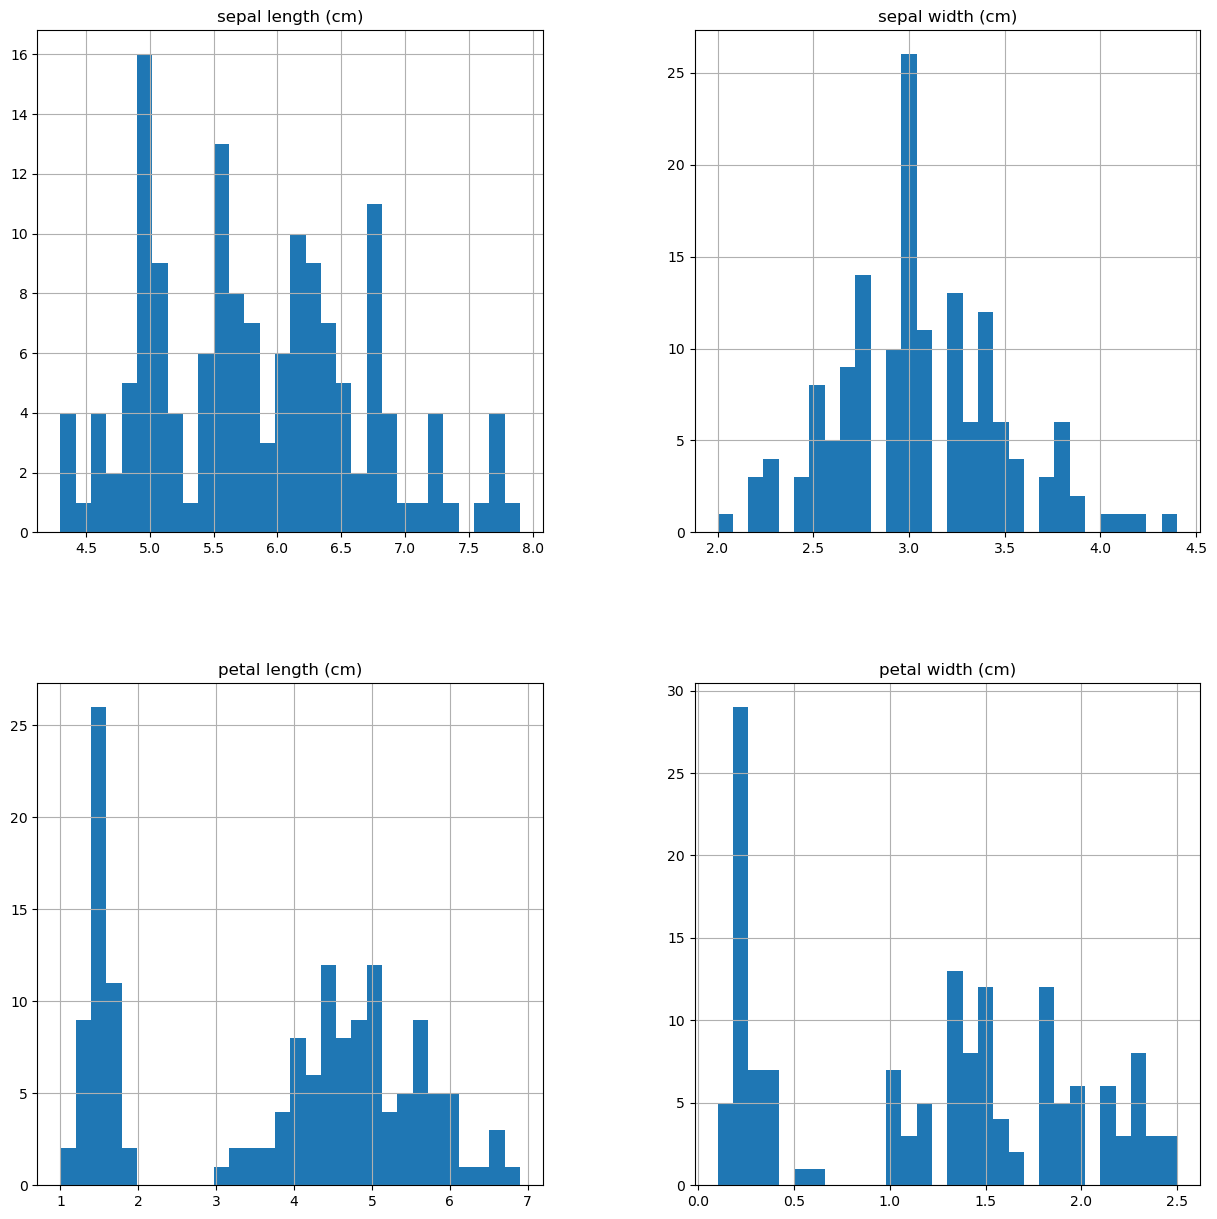

In [13]:
# Histogramy dla zmiennych ilościowych

iris_df[predictors].hist(bins=30, figsize=(15,15))
plt.show()

In [14]:
def plot_box_strip(df, variables, hue=None):
    """
    Tworzy wykresy pudełkowe z nałożonymi punktami obserwacji dla podanych zmiennych.

    Parametry:
    - df: DataFrame zawierający dane,
    - variables: lista nazw kolumn ze zmiennymi ilościowymi,
    - hue: opcjonalna zmienna grupująca.
    """

    for var in variables:
        plt.figure(figsize=(8, 6))

        sns.boxplot(
            data=df,
            y=var,
            x=hue,
            fliersize=0,
            color="green"
        )

        sns.stripplot(
            data=df,
            y=var,
            x=hue,
            jitter=0.1,
            alpha=0.3,
            color="black"
        )

        plt.title(f"Wykres pudełkowy z obserwacjami: {var}")
        plt.xlabel(hue if hue else "")
        plt.ylabel(var)
        plt.tight_layout()
        plt.show()

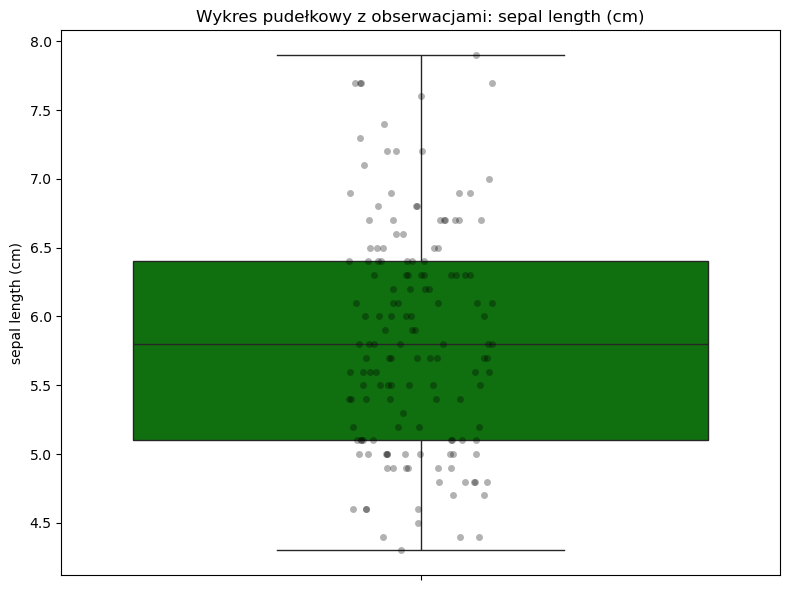

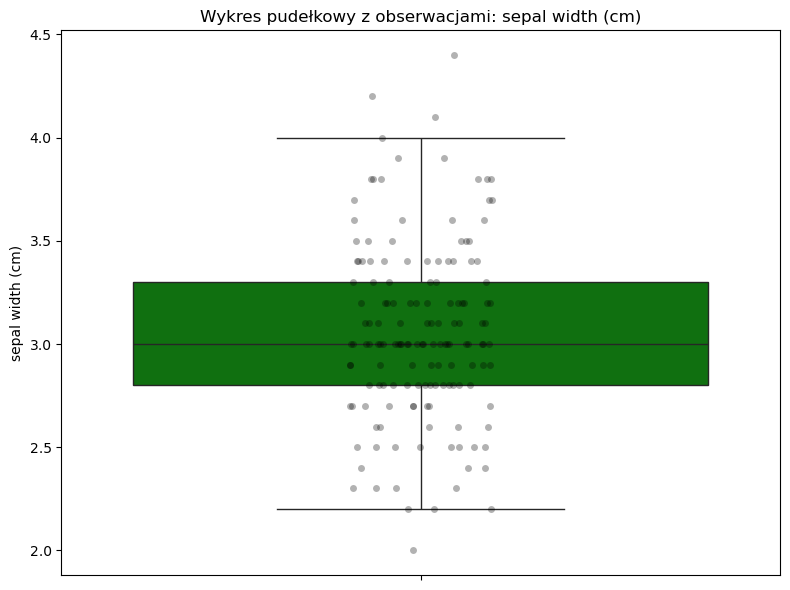

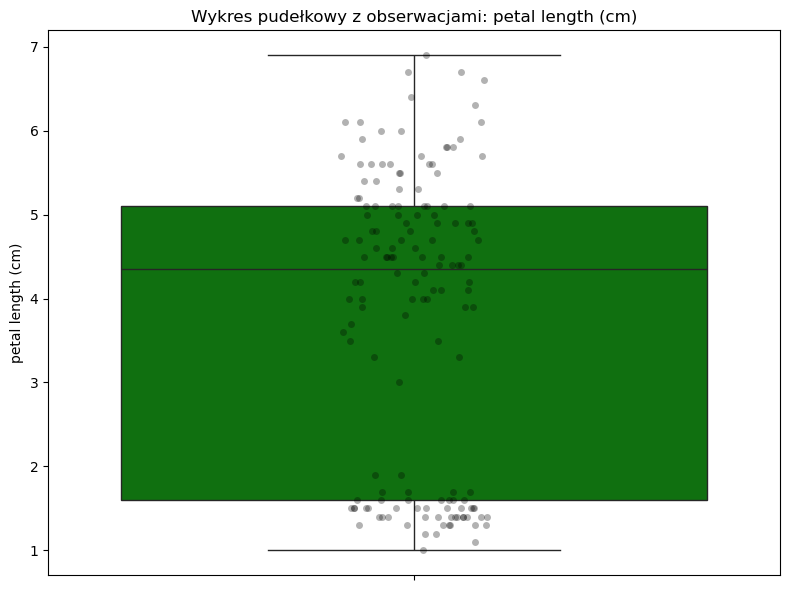

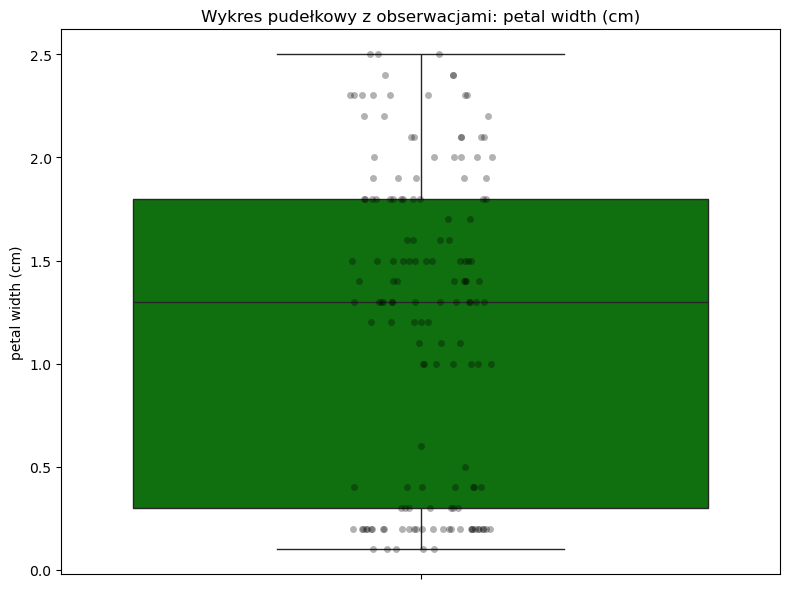

In [15]:
# Wykresy pudełkowe (ramka-wąsy) dla zmiennych używanych w analizie skupień
plot_box_strip(iris_df,predictors)

Na podstawie wykresów pudełkowych i histogramów możemy ocenić, czy w danych występują obserwacje nietypowe oraz czy rozkłady zmiennych są symetryczne czy skośne.

W zbiorze Iris nie widać poważnych problemów z brakami danych.  
Potencjalne wartości odstające należy jednak interpretować ostrożnie — w analizie skupień nietypowe obserwacje nie zawsze są błędami. Czasami mogą wskazywać na obiekty, które rzeczywiście różnią się od pozostałych.

In [16]:
# Podsumowanie podstawowych statystyk opisowych dla zmiennych używanych w analizie skupień

iris_df[predictors].describe().T

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


## Analiza zmiennej referencyjnej

W tym zbiorze kolumna `species` zawiera rzeczywistą odmianę irysa.  
Nie będzie ona używana do budowy modelu KMeans, ale przyda się później do interpretacji i zewnętrznej oceny jakości skupień.

Na tym etapie sprawdzimy, ile obserwacji należy do każdej odmiany.

In [17]:
# Graficzna analiza rozkładu zmiennych referencyjnych / jakościowych

def plot_categorical_bars(df, categorical_vars):
    """
    Tworzy wykresy słupkowe dla wybranych zmiennych jakościowych.

    Parametry:
    - df: DataFrame zawierający dane,
    - categorical_vars: lista nazw kolumn jakościowych lub referencyjnych.
    """
    for var in categorical_vars:
        plt.figure(figsize=(6, 4))

        df[var].value_counts().plot(
            kind="bar",
            color="skyblue",
            edgecolor="black"
        )

        plt.title(f"Liczność kategorii dla zmiennej: {var}")
        plt.xlabel(var)
        plt.ylabel("Liczność")
        plt.xticks(rotation=45)
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.tight_layout()
        plt.show()

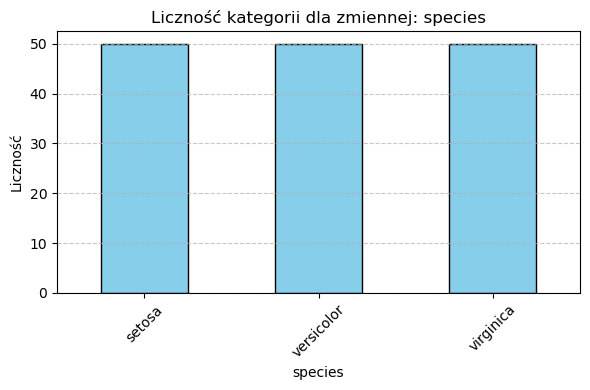

In [18]:
plot_categorical_bars(iris_df, additional)

In [19]:
# Tabela liczności dla zmiennych jakościowych / referencyjnych

def categorical_summary(df, column):
    """
    Tworzy tabelę liczności dla jednej zmiennej jakościowej.

    Parametry:
    - df: DataFrame zawierający dane,
    - column: nazwa kolumny jakościowej.

    Zwraca:
    - DataFrame z licznością i procentowym udziałem kategorii.
    """
    counts = df[column].value_counts(dropna=False)
    labels = counts.index.fillna("Brak danych").astype(str)
    percentages = (counts / counts.sum() * 100).round(2)

    return pd.DataFrame({
        "Etykieta": labels,
        "Liczność": counts.values,
        "Procent": percentages.values
    })

In [20]:
for var in additional:
    display(categorical_summary(iris_df, var))

,Etykieta,Liczność,Procent
0,setosa,50,33.33
1,versicolor,50,33.33
2,virginica,50,33.33


W zbiorze Iris klasy są zrównoważone — każda odmiana występuje w tej samej liczbie obserwacji.  
To ułatwia późniejsze porównanie wyniku analizy skupień z rzeczywistymi odmianami.

W praktycznych projektach taka sytuacja nie zawsze występuje. Jeżeli jedna kategoria jest bardzo rzadka, porównywanie skupień z taką zmienną referencyjną wymaga większej ostrożności.

## Czyszczenie danych: wartości odstające

Po wstępnym rozpoznaniu danych przechodzimy do oceny potencjalnych wartości odstających.

Wartości odstające nie zawsze są błędami. Mogą oznaczać:

- pomyłkę w danych,
- nietypową, ale poprawną obserwację,
- obiekt, który rzeczywiście różni się od pozostałych.

W analizie skupień trzeba być szczególnie ostrożnym, ponieważ obserwacje odstające mogą wpływać na położenie centroidów i tym samym na wynik działania algorytmu KMeans.

W tym przykładzie zastosujemy winsoryzację, czyli przycięcie wartości skrajnych do granic uznanych za typowe. Traktujemy to jako demonstrację techniki przygotowania danych.

## Zrozumieliśmy dane teraz zaczynamy ich czyszczenie
### Na początek wartości odstające

1. Wartości spoza zakresu "obcinamy" do granic uznanych za typowe
2. Wartości ekstrematnie nietypowe być może będziemy musieli usunąć z analizy

In [21]:
# Zachowujemy kopię danych przed ewentualnym przycinaniem wartości odstających.
# Dzięki temu w razie potrzeby możemy wrócić do pierwotnej wersji danych.

iris_df_original = iris_df.copy()

# capping_method='iqr' - metoda oparta na rozstępie kwartylowym
# fold=1.5 - parametr sterujący szerokością granic przycinania
# tail='both' - przycinanie wartości odstających z obu stron rozkładu

winsorizer = Winsorizer(
    capping_method="iqr",
    fold=1.5,
    tail="both"
)

iris_df[predictors] = winsorizer.fit_transform(iris_df[predictors])

### Sprawdzenie efektu winsoryzacji

Po przycięciu wartości skrajnych ponownie oglądamy wykresy pudełkowe.  
Celem nie jest mechaniczne „usunięcie problemu”, ale sprawdzenie, jak zmienił się zakres wartości zmiennych oraz czy potencjalne obserwacje odstające zostały ograniczone.

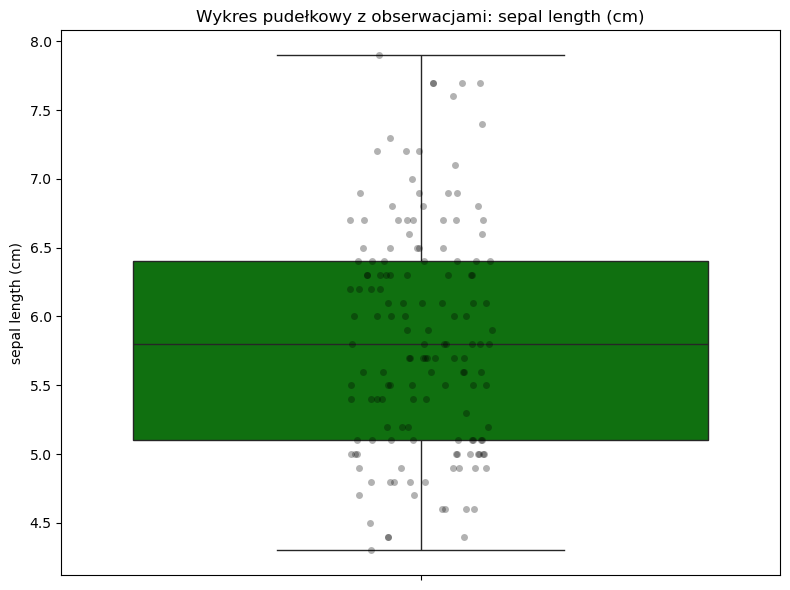

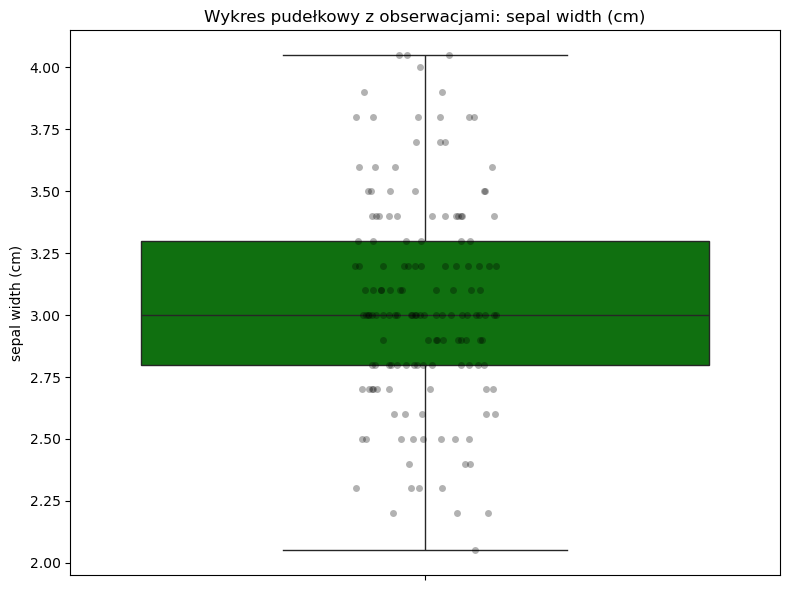

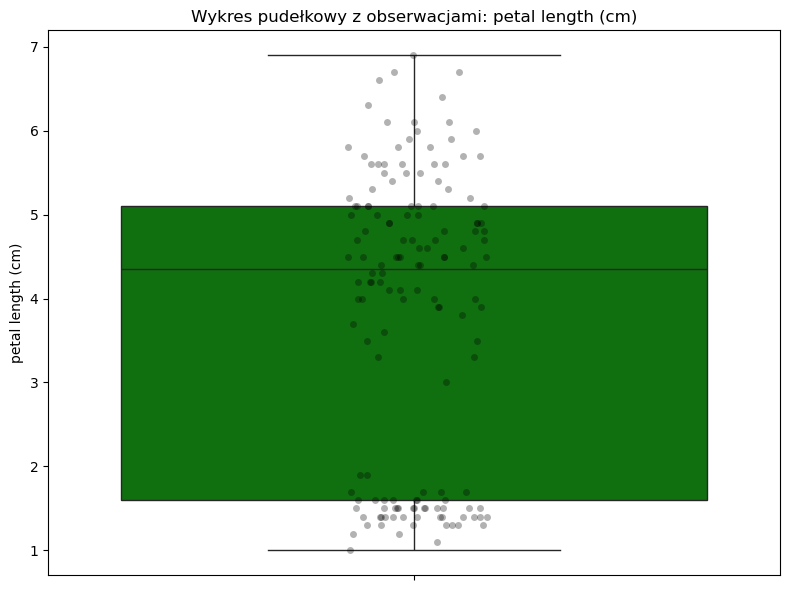

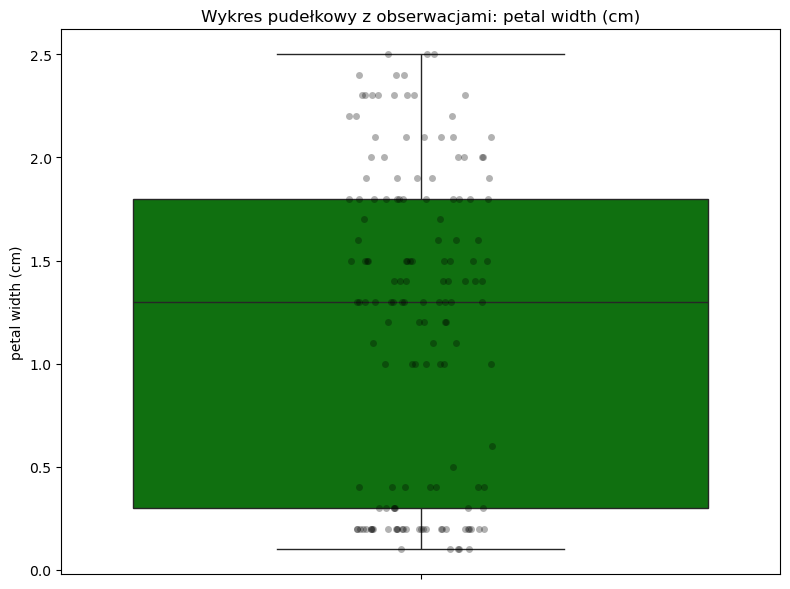

In [22]:
plot_box_strip(iris_df,predictors)

## Sprawdźmy powiązania pomiędzy zmiennymi

Przed budową modelu warto sprawdzić, czy zmienne są ze sobą powiązane.  
W analizie skupień jest to ważne z kilku powodów:

- silnie skorelowane zmienne mogą wnosić częściowo podobną informację,
- zależności między zmiennymi pomagają lepiej zrozumieć strukturę danych,
- wizualizacja relacji może podpowiedzieć, czy w danych widać naturalne grupy obserwacji.

W tym celu:

- obliczymy korelacje między zmiennymi za pomocą współczynnika Spearmana,
- przedstawimy je graficznie na mapie ciepła,
- obejrzymy wybrane wykresy rozrzutu,
- a przy niewielkiej liczbie zmiennych pokażemy też macierz wykresów rozrzutu.

In [23]:
# Obliczanie macierzy korelacji rang Spearmana

spearman_corr_matrix = iris_df[predictors].corr(method='spearman')

spearman_corr_matrix

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.166871,0.881898,0.834289
sepal width (cm),-0.166871,1.000000,-0.309636,-0.289184
petal length (cm),0.881898,-0.309636,1.000000,0.937667
petal width (cm),0.834289,-0.289184,0.937667,1.000000


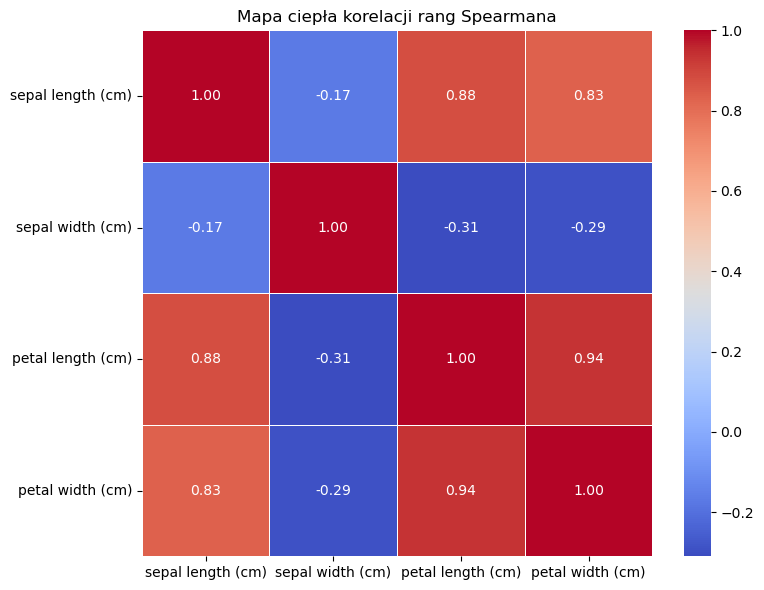

In [24]:
# Graficzne przedstawienie korelacji w postaci mapy ciepła

plt.figure(figsize=(8, 6))

sns.heatmap(
    spearman_corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Mapa ciepła korelacji rang Spearmana")
plt.tight_layout()
plt.show()

Mapa ciepła pozwala szybko ocenić, które pary zmiennych są ze sobą silniej, a które słabiej powiązane.

Wysoka korelacja nie oznacza automatycznie, że którąś zmienną trzeba usunąć.  
Na tym etapie traktujemy ją przede wszystkim jako informację pomagającą lepiej zrozumieć dane.

In [25]:
# Funkcja tworząca wykres rozrzutu dla dwóch wybranych zmiennych

def scatter_plot(df, variables, hue=None):
    """
    Tworzy wykres rozrzutu dla dwóch podanych zmiennych.

    Parametry:
    - df: DataFrame z danymi
    - variables: lista dokładnie 2 nazw kolumn [x, y]
    - hue: opcjonalna zmienna jakościowa do kolorowania punktów
    """

    if len(variables) != 2:
        raise ValueError("Lista 'variables' musi zawierać dokładnie 2 zmienne.")

    x, y = variables

    plt.figure(figsize=(8, 6))

    if hue:
        sns.scatterplot(data=df, x=x, y=y, hue=hue, palette="Set1", alpha=0.7)
        plt.legend(title=hue)
    else:
        sns.scatterplot(data=df, x=x, y=y, alpha=0.7)

    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"Wykres rozrzutu: {x} vs {y}")
    plt.tight_layout()
    plt.show()

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


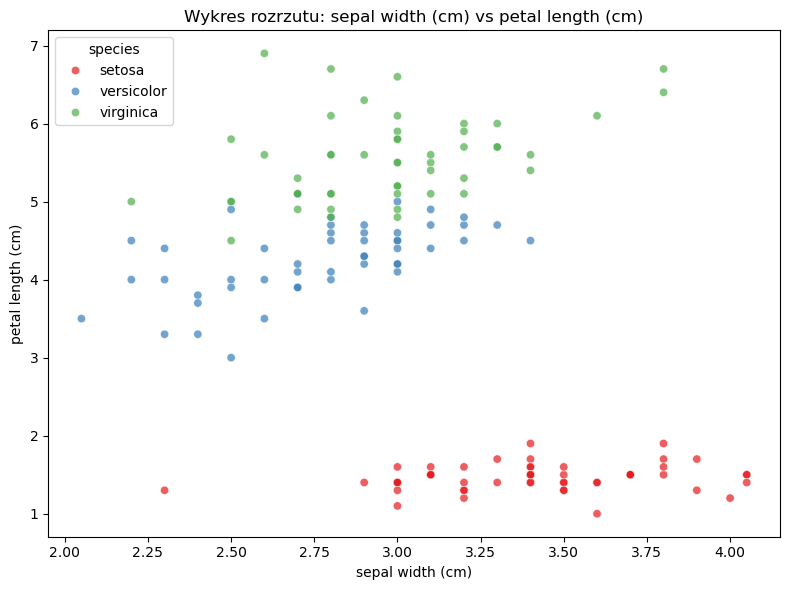

In [26]:
print(predictors)

scatter_plot(iris_df, ['sepal width (cm)', 'petal length (cm)'], 'species')

W przypadku mniejszej listy zmiennych możemy przedstawić wszystkie zmienne na zbiorczym wykresie

In [27]:
# Macierz wykresów rozrzutu dla wszystkich zmiennych ilościowych

def scatter_matrix_plot(df, variables, hue=None):
    """
    Tworzy macierzowy wykres rozrzutu dla podanych zmiennych ilościowych.

    Parametry:
    - df: DataFrame zawierający dane
    - variables: lista nazw kolumn dla zmiennych ilościowych
    - hue: opcjonalna zmienna jakościowa do kolorowania punktów
    """
    sns.pairplot(
        df,
        vars=variables,
        hue=hue,
        palette="Set1" if hue else None,
        corner=True
    )
    plt.show()

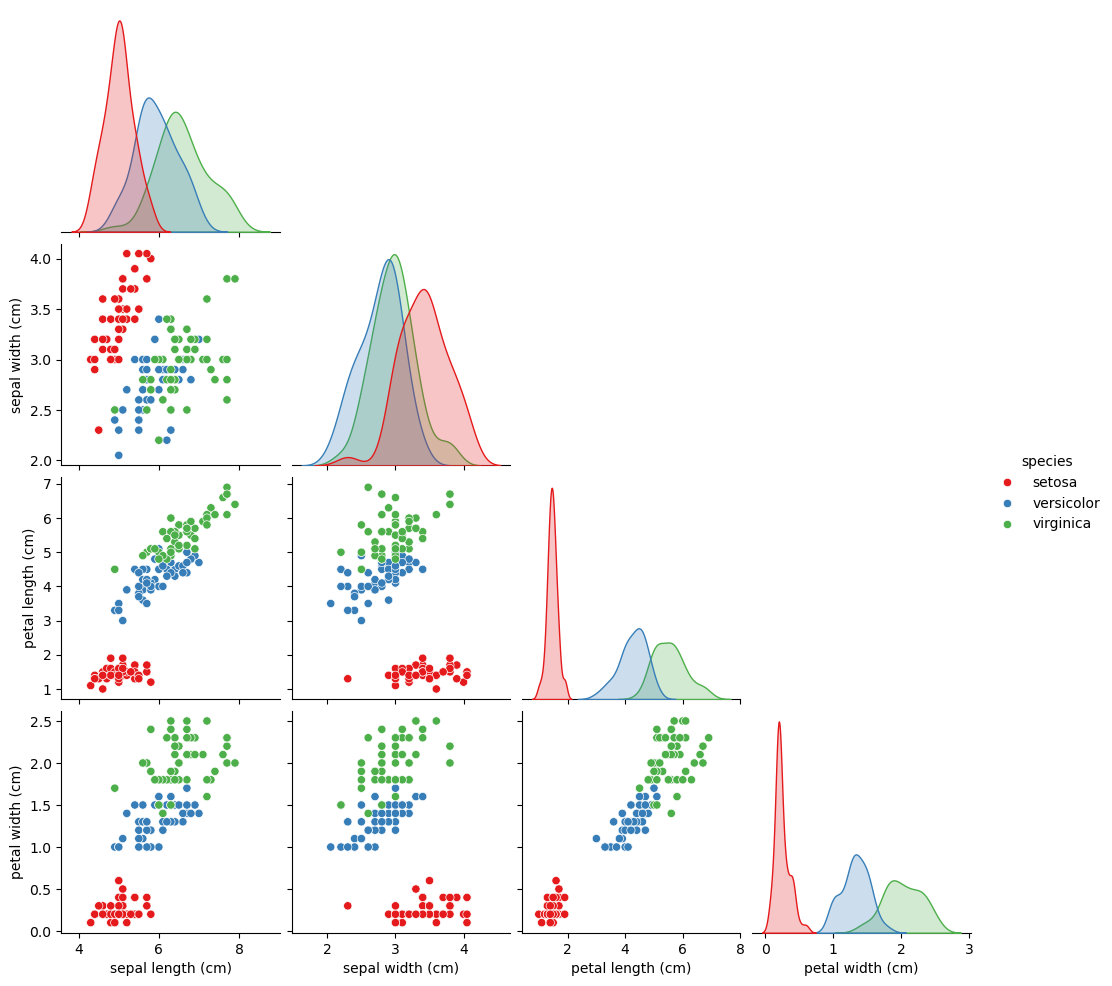

In [28]:
scatter_matrix_plot(iris_df, predictors, hue='species')

Macierz wykresów rozrzutu pozwala jednocześnie obejrzeć zależności pomiędzy wszystkimi parami zmiennych.

W zbiorze Iris taka wizualizacja jest szczególnie użyteczna, ponieważ przy zaledwie czterech zmiennych można szybko ocenić, czy obserwacje tworzą potencjalne grupy oraz które cechy najlepiej je rozdzielają.

## Skalowanie danych

Algorytm KMeans opiera się na odległościach między obserwacjami.  
Oznacza to, że zmienne o większym zakresie wartości mogłyby silniej wpływać na wynik grupowania niż zmienne o mniejszym zakresie.

Dlatego przed budową modelu przeskalujemy dane do wspólnego zakresu.  
W tym przykładzie użyjemy skalowania Min-Max, które przekształca wartości każdej zmiennej do przedziału od 0 do 1.

Wynik skalowania zapiszemy w nowej ramce danych, aby zachować także wersję oryginalną.

In [29]:
# Skalowanie wartości predyktorów
# Zachowujemy oryginalną ramkę danych i tworzymy jej kopię

scaled_iris_df = iris_df.copy()

min_max_scaler = MinMaxScaler()

scaled_iris_df[predictors] = min_max_scaler.fit_transform(scaled_iris_df[predictors])

scaled_iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,0.222222,0.725,0.067797,0.041667,setosa
1,0.166667,0.475,0.067797,0.041667,setosa
2,0.111111,0.575,0.050847,0.041667,setosa
3,0.083333,0.525,0.084746,0.041667,setosa
4,0.194444,0.775,0.067797,0.041667,setosa


### Sprawdzenie efektu skalowania

Po skalowaniu ponownie oglądamy rozkłady zmiennych.  
Interesuje nas przede wszystkim to, że wszystkie zmienne zostały sprowadzone do wspólnego zakresu, co ułatwi ich porównywanie i ograniczy dominację jednej cechy nad innymi w procesie grupowania.

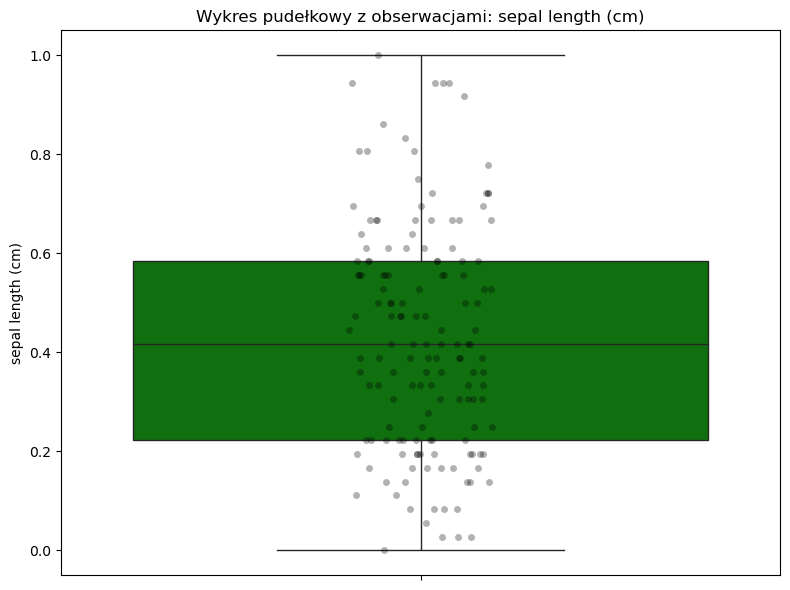

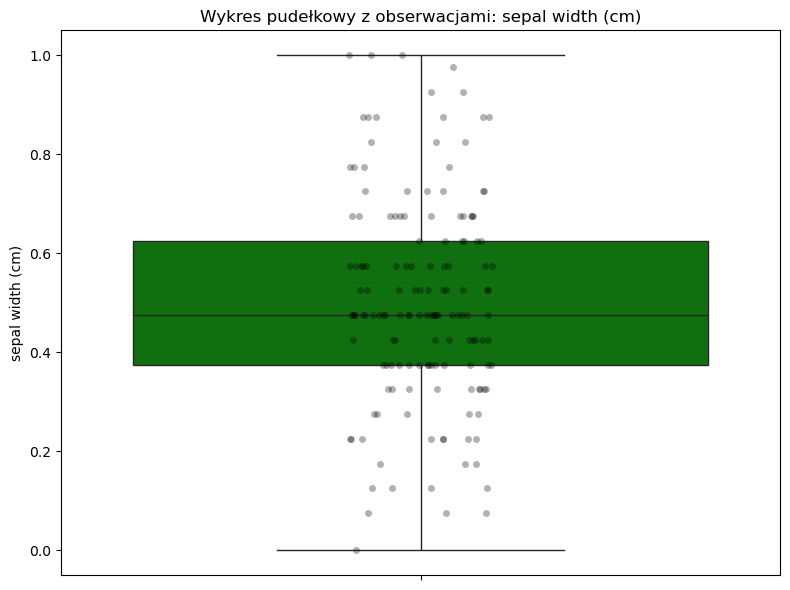

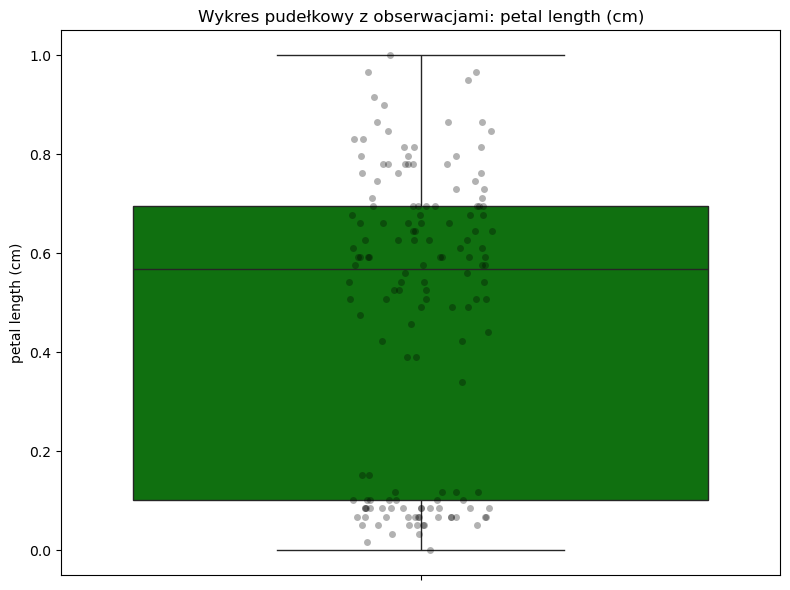

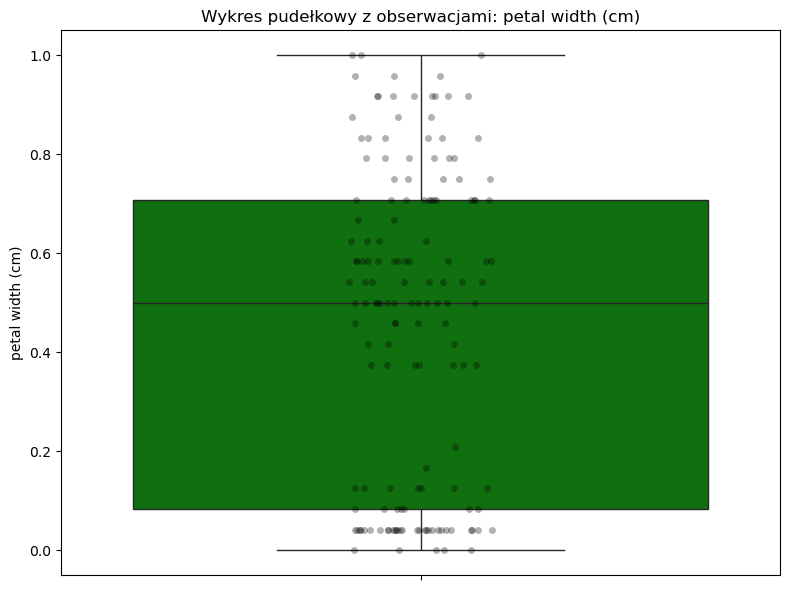

In [30]:
plot_box_strip(scaled_iris_df,predictors)

In [31]:
# Porównanie podstawowych statystyk przed i po skalowaniu

comparison = pd.concat(
    {
        "Przed skalowaniem": iris_df[predictors].describe().T[["min", "max"]],
        "Po skalowaniu": scaled_iris_df[predictors].describe().T[["min", "max"]]
    },
    axis=1
)

comparison

Przed skalowaniem       Po skalowaniu     
                                min   max           min  max
sepal length (cm)              4.30  7.90           0.0  1.0
sepal width (cm)               2.05  4.05           0.0  1.0
petal length (cm)              1.00  6.90           0.0  1.0
petal width (cm)               0.10  2.50           0.0  1.0

## Budujemy pierwszy model analizy skupień

W modelu KMeans musimy z góry podać liczbę skupień.  
Na początek przyjmiemy wstępnie, że w danych występują **3 skupienia**.

Po zbudowaniu modelu:

- przypiszemy każdą obserwację do jednego skupienia,
- zapiszemy wynik zarówno do ramki z danymi surowymi, jak i do ramki z danymi przeskalowanymi.

Warto pamiętać, że etykiety skupień nadawane przez model (np. 0, 1, 2) są jedynie technicznymi oznaczeniami grup.  
Nie oznaczają one żadnego naturalnego uporządkowania.

In [32]:
# Ewentualne ostrzeżenia można wyłączyć
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)

# Podaj liczbę skupień
n_clusters = 3

# Budowa modelu KMeans
kmeans_model = KMeans(
    n_clusters=n_clusters,
    random_state=seed,
    n_init=10
)

# Dopasowanie modelu i przypisanie obserwacji do skupień
kmeans_model_classes = kmeans_model.fit_predict(scaled_iris_df[predictors])

# Zapis etykiet skupień do obu ramek danych
iris_df['predicted_class'] = kmeans_model_classes
scaled_iris_df['predicted_class'] = kmeans_model_classes

predicted_class oznacza tu etykietę skupienia nadaną przez algorytm, a nie klasę przewidywaną w sensie klasyfikacji nadzorowanej.

In [33]:
# Podgląd danych z przypisanym skupieniem
iris_df.head(20)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,predicted_class
0,5.1,3.50,1.4,0.2,setosa,0
1,4.9,3.00,1.4,0.2,setosa,0
2,4.7,3.20,1.3,0.2,setosa,0
3,4.6,3.10,1.5,0.2,setosa,0
4,5.0,3.60,1.4,0.2,setosa,0
5,5.4,3.90,1.7,0.4,setosa,0
6,4.6,3.40,1.4,0.3,setosa,0
7,5.0,3.40,1.5,0.2,setosa,0
8,4.4,2.90,1.4,0.2,setosa,0
9,4.9,3.10,1.5,0.1,setosa,0


## Chcemy teraz zrozumieć uzyskane wyniki

Po zbudowaniu modelu nie wystarczy tylko przypisać obserwacje do skupień.  
Trzeba jeszcze sprawdzić, jak wygląda otrzymany podział.

W tym celu:

- ocenimy liczność obserwacji w poszczególnych skupieniach,
- sprawdzimy średnie wartości zmiennych w skupieniach,
- obejrzymy profile skupień na danych przeskalowanych,
- zobaczymy rozkład zmiennych w przekroju skupień.

Dzięki temu będziemy mogli ocenić, czy uzyskane grupy są sensowne i czy rzeczywiście różnią się między sobą.

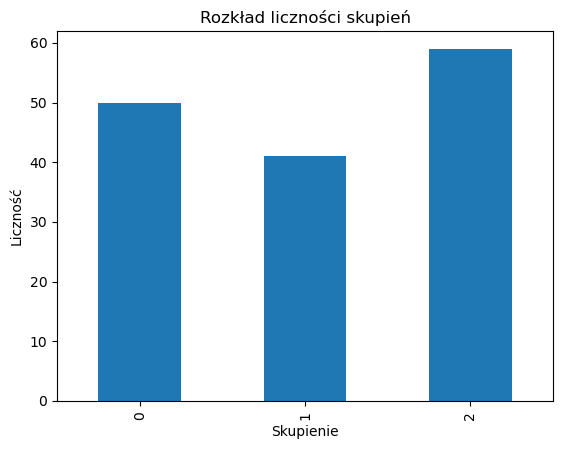

In [34]:
# Liczność obserwacji w poszczególnych skupieniach

iris_df["predicted_class"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Skupienie")
plt.ylabel("Liczność")
plt.title("Rozkład liczności skupień")

plt.show()

Liczność skupień pozwala ocenić, czy model nie tworzy bardzo małych, podejrzanych grup.  
Niewielkie skupienie nie musi oznaczać błędu, ale może sugerować, że model wymaga dalszej analizy lub zmiany liczby skupień.

In [35]:
# Grupowanie danych po skupieniu i obliczenie średnich dla danych surowych

means = iris_df.groupby("predicted_class")[predictors].mean()

means

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
predicted_class,,,,
0,5.006000,3.417000,1.462000,0.246000
1,6.829268,3.087805,5.653659,2.053659
2,5.867797,2.722881,4.386441,1.413559


In [36]:
# Grupowanie danych po skupieniu i obliczenie średnich dla danych przeskalowanych

means_scaled = scaled_iris_df.groupby("predicted_class")[predictors].mean()

means_scaled

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
predicted_class,,,,
0,0.196111,0.683500,0.078305,0.060833
1,0.702575,0.518902,0.788756,0.814024
2,0.435499,0.336441,0.573973,0.547316


Średnie wartości zmiennych w skupieniach pomagają zrozumieć profil każdej grupy.

Średnie na danych surowych są łatwiejsze do interpretacji merytorycznej,  
natomiast średnie na danych przeskalowanych lepiej nadają się do porównywania zmiennych między skupieniami na jednym wykresie.

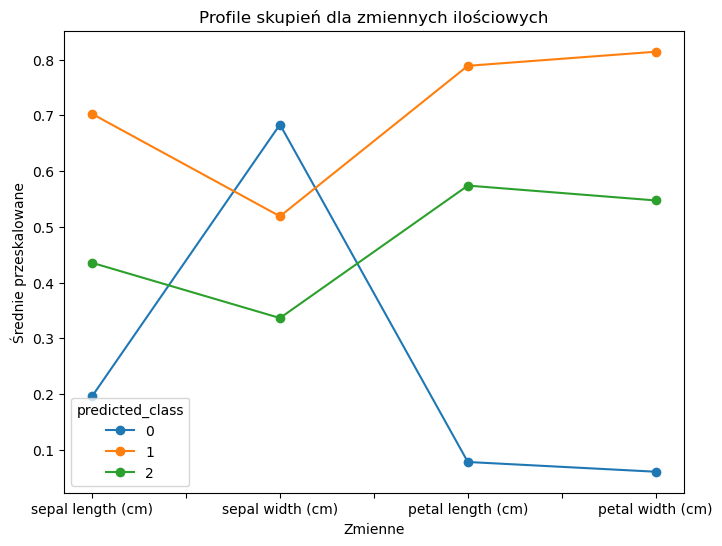

In [37]:
# Wykres średnich przeskalowanych zmiennych w poszczególnych skupieniach

means_scaled.T.plot(marker="o", linestyle="-", figsize=(8, 6))

plt.xlabel("Zmienne")
plt.ylabel("Średnie przeskalowane")
plt.title("Profile skupień dla zmiennych ilościowych")

plt.show()

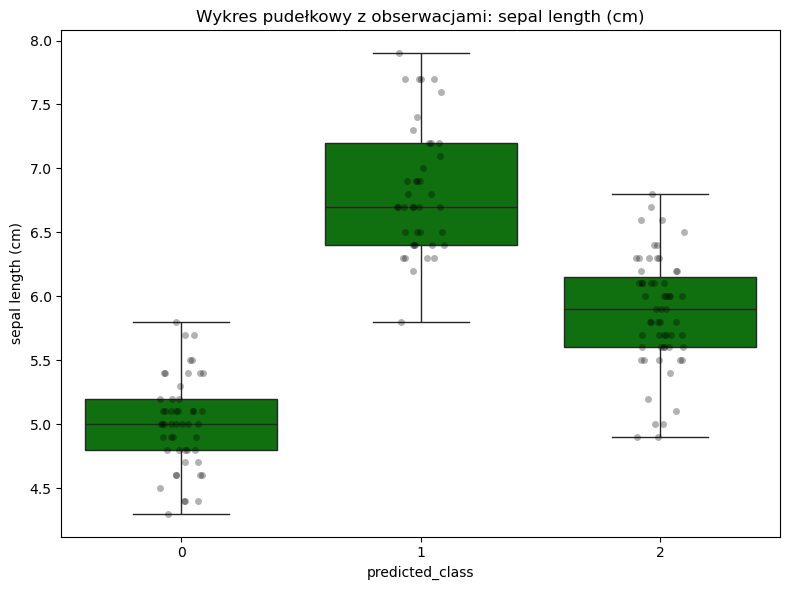

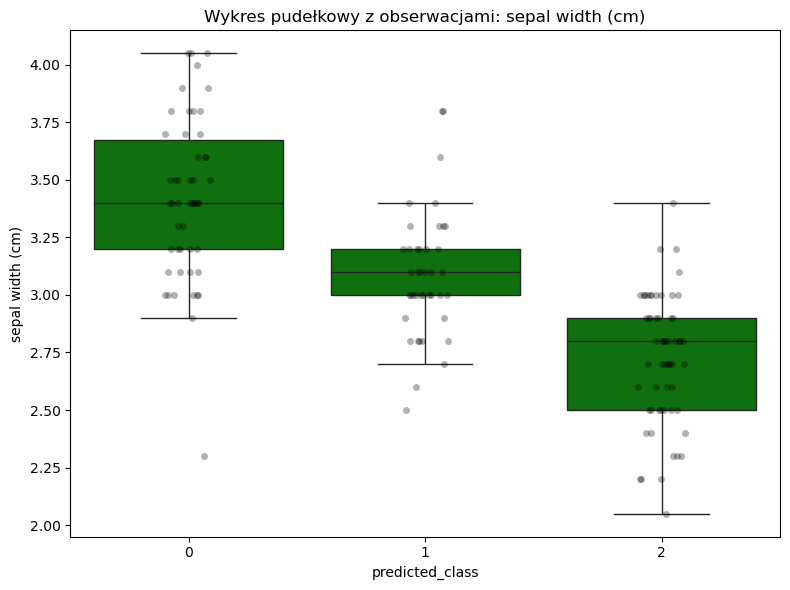

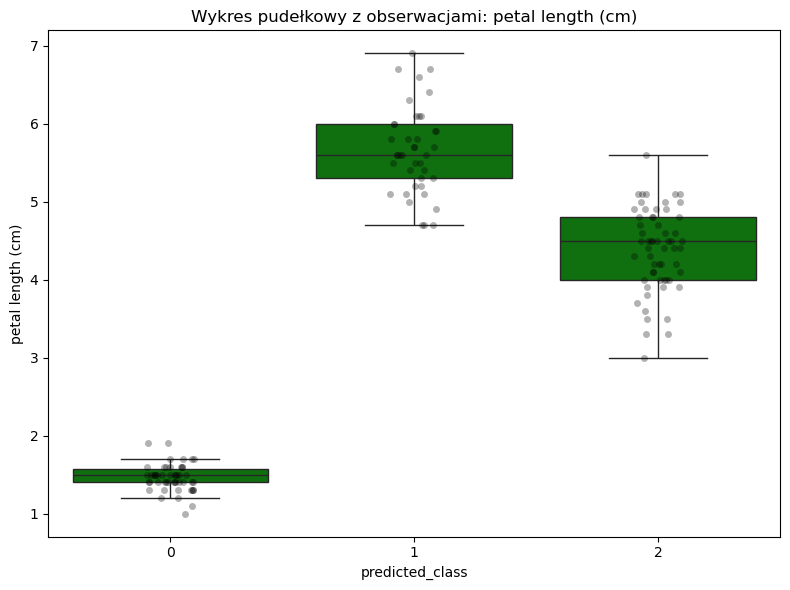

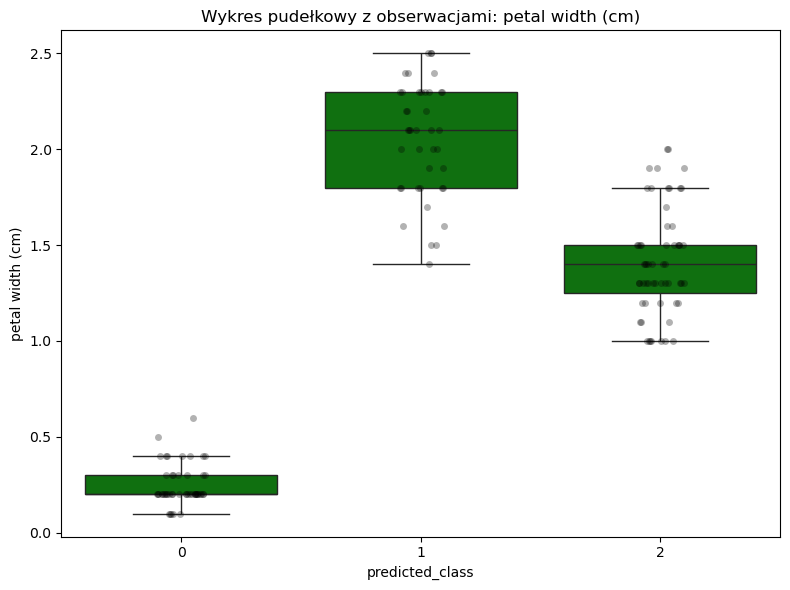

In [38]:
# Wykresy pudełkowe zmiennych w przekroju skupień

plot_box_strip(iris_df, predictors, hue="predicted_class")


## Porównanie skupień ze zmienną referencyjną `species`

Zmienna `species` nie była używana podczas budowy modelu KMeans.  
Możemy jednak wykorzystać ją po zakończeniu grupowania, aby sprawdzić, na ile otrzymane skupienia odpowiadają rzeczywistym odmianom irysa.

W tym celu tworzymy tabelę kontyngencji, która pokazuje, ile obserwacji z każdej odmiany trafiło do poszczególnych skupień.

In [39]:
# Tabela kontyngencji: skupienia KMeans vs rzeczywista odmiana irysa

contingency_table = pd.crosstab(
    iris_df["predicted_class"],
    iris_df["species"]
)

contingency_table

species,setosa,versicolor,virginica
predicted_class,,,
0,50,0,0
1,0,5,36
2,0,45,14


In [40]:
# Tabela kontyngencji w procentach w obrębie skupień

contingency_table_percent = pd.crosstab(
    iris_df["predicted_class"],
    iris_df["species"],
    normalize="index"
).round(3) * 100

contingency_table_percent

species,setosa,versicolor,virginica
predicted_class,,,
0,100.0,0.0,0.0
1,0.0,12.2,87.8
2,0.0,76.3,23.7


Wiersze tabeli odpowiadają skupieniom utworzonym przez KMeans, a kolumny rzeczywistym odmianom irysa.

Jeżeli jedno skupienie zawiera prawie wyłącznie jedną odmianę, oznacza to dobrą zgodność tego skupienia ze zmienną referencyjną.  
Jeżeli w jednym skupieniu miesza się wiele odmian, oznacza to, że model nie rozdziela ich jednoznacznie na podstawie użytych cech.

## Ocena modelu: wskaźnik sylwetki

Do oceny jakości podziału na skupienia możemy wykorzystać **wskaźnik sylwetki**.

Wskaźnik sylwetki mierzy, jak dobrze dana obserwacja pasuje do własnego skupienia w porównaniu z innymi skupieniami.  
Wartości wskaźnika mieszczą się zwykle w przedziale od -1 do 1.

Ogólna interpretacja:

- wartości bliskie 1 oznaczają, że obserwacje są dobrze dopasowane do swoich skupień,
- wartości około 0 oznaczają, że obserwacje leżą blisko granicy między skupieniami,
- wartości ujemne sugerują, że część obserwacji mogłaby być lepiej przypisana do innego skupienia.

Warto jednak pamiętać, że nie ma jednego uniwersalnego progu dobrej jakości klasteryzacji.  
Wskaźnik sylwetki najlepiej sprawdza się przy porównywaniu kilku wariantów modelu, np. dla różnej liczby skupień.

In [41]:
from sklearn.metrics import silhouette_score, silhouette_samples

# Obliczenie średniego wskaźnika sylwetki dla całego modelu

silhouette_avg = silhouette_score(
    scaled_iris_df[predictors],
    scaled_iris_df["predicted_class"]
)

print(f"Wartość wskaźnika sylwetki: {silhouette_avg:.4f}")

Wartość wskaźnika sylwetki: 0.4890


Średnia wartość wskaźnika sylwetki daje ogólną ocenę jakości podziału, ale nie pokazuje, czy wszystkie skupienia są równie dobre.

Dlatego warto obejrzeć także wykres sylwetki.  
Pozwala on sprawdzić, czy w niektórych skupieniach występują obserwacje słabo dopasowane lub potencjalnie błędnie przypisane.

In [42]:
def plot_silhouette(data, cluster_column, predictors):
    """
    Tworzy wykres wskaźnika sylwetki dla danych po klasteryzacji.

    Parametry:
    - data: DataFrame zawierający zmienne używane do klasteryzacji oraz kolumnę z etykietami skupień,
    - cluster_column: nazwa kolumny zawierającej etykiety skupień,
    - predictors: lista nazw kolumn zawierających cechy używane do klasteryzacji.
    """

    # Obliczenie wartości sylwetki dla każdej obserwacji
    silhouette_vals = silhouette_samples(
        data[predictors],
        data[cluster_column]
    )

    # Pobranie unikalnych etykiet skupień
    clusters = np.unique(data[cluster_column])

    # Średnia wartość wskaźnika sylwetki
    silhouette_avg = silhouette_score(
        data[predictors],
        data[cluster_column]
    )

    plt.figure(figsize=(8, 6))

    y_lower = 0

    for cluster in clusters:
        cluster_vals = silhouette_vals[data[cluster_column] == cluster]
        cluster_vals.sort()

        y_upper = y_lower + len(cluster_vals)

        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            cluster_vals,
            alpha=0.7,
            label=f"Skupienie {cluster}"
        )

        # Oddzielenie skupień niewielką przerwą
        y_lower = y_upper + 5

    # Linia oznaczająca średni wskaźnik sylwetki
    plt.axvline(
        x=silhouette_avg,
        color="red",
        linestyle="--",
        label=f"Średnia sylwetka = {silhouette_avg:.3f}"
    )

    plt.xlabel("Wartość wskaźnika sylwetki")
    plt.ylabel("Obserwacje pogrupowane według skupień")
    plt.title("Wykres sylwetki dla modelu KMeans")
    plt.legend()
    plt.tight_layout()
    plt.show()

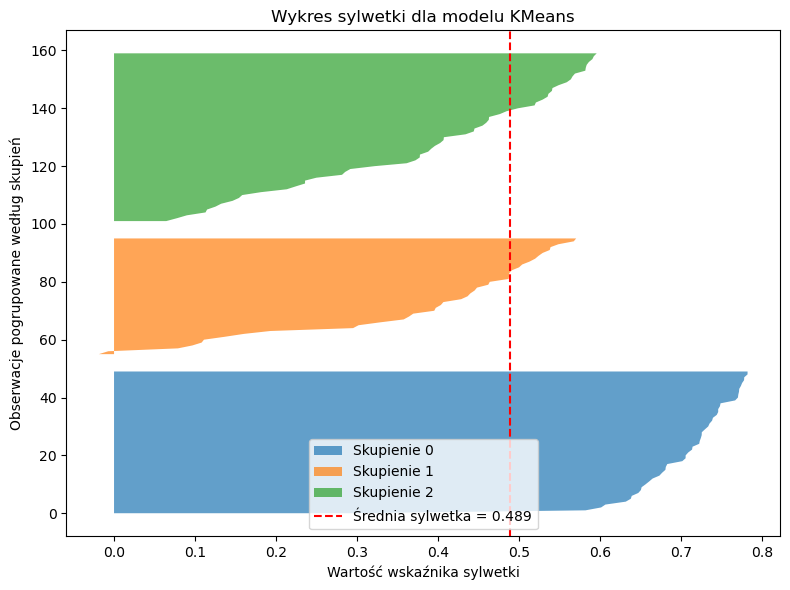

In [43]:
plot_silhouette(scaled_iris_df,"predicted_class",predictors)

Na wykresie sylwetki warto zwrócić uwagę na trzy rzeczy:

- czy większość obserwacji ma dodatnie wartości wskaźnika,
- czy poszczególne skupienia mają podobną jakość dopasowania,
- czy w którymś skupieniu pojawia się dużo obserwacji z wartościami bliskimi 0 lub ujemnymi.

Jeżeli wiele obserwacji ma niskie lub ujemne wartości sylwetki, może to sugerować, że liczba skupień została dobrana nieoptymalnie albo że struktura danych nie odpowiada dobrze założeniom modelu KMeans.

## Zewnętrzna ocena zgodności skupień z odmianą irysa

W zbiorze Iris mamy dodatkową informację o rzeczywistej odmianie kwiatu, zapisaną w kolumnie `species`.

Ta zmienna nie była używana podczas budowy modelu KMeans, ale możemy wykorzystać ją po zakończeniu grupowania do oceny, czy otrzymane skupienia są zgodne z rzeczywistymi odmianami.

Do takiej oceny wykorzystamy **skorygowany indeks Randa**, czyli **Adjusted Rand Index (ARI)**.

Ogólna interpretacja ARI:

- wartość bliska 1 oznacza bardzo dużą zgodność skupień ze zmienną referencyjną,
- wartość bliska 0 oznacza zgodność podobną do losowego przypisania,
- wartości ujemne oznaczają zgodność gorszą niż losowa.

Ważne: ARI nie wymaga, aby numery skupień odpowiadały numerom lub nazwom klas.  
Liczy się zgodność podziału obserwacji na grupy, a nie same etykiety skupień.

In [44]:
from sklearn.metrics import adjusted_rand_score

# Obliczenie skorygowanego indeksu Randa.
# Porównujemy rzeczywistą odmianę irysa ze skupieniem nadanym przez KMeans.

ari_score = adjusted_rand_score(
    scaled_iris_df["species"],
    scaled_iris_df["predicted_class"]
)

print(f"Skorygowany indeks Randa (ARI): {ari_score:.4f}")

Skorygowany indeks Randa (ARI): 0.6898


ARI pozwala ocenić, na ile podział uzyskany przez KMeans jest podobny do rzeczywistego podziału na odmiany irysa.

## Dobór liczby skupień

W modelu KMeans liczba skupień `k` musi zostać podana przed rozpoczęciem modelowania.  
W praktyce zwykle nie wiemy z góry, jaka liczba skupień będzie najlepsza, dlatego warto porównać kilka wariantów modelu.

Sprawdzimy modele dla różnych wartości `k` i porównamy je za pomocą:

- inercji, czyli sumy odległości obserwacji od centroidów,
- wskaźnika sylwetki,
- wskaźnika Calinskiego-Harabasza,
- wskaźnika Daviesa-Bouldina.

Warto pamiętać, że żadna z tych miar nie podejmuje decyzji automatycznie.  
Są one narzędziami wspierającymi ocenę, a ostateczny wybór liczby skupień powinien uwzględniać także interpretowalność wyniku.

In [45]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Zakres liczby skupień
cluster_range = range(2, 11)

# Listy do zapisania wyników
inertia_values = []
silhouette_values = []
calinski_harabasz_values = []
davies_bouldin_values = []

# Pętla dla różnych wartości k
for k in cluster_range:
    model = KMeans(
        n_clusters=k,
        random_state=seed,
        n_init=10
    )
    
    labels = model.fit_predict(scaled_iris_df[predictors])
    
    inertia_values.append(model.inertia_)
    silhouette_values.append(
        silhouette_score(scaled_iris_df[predictors], labels)
    )
    calinski_harabasz_values.append(
        calinski_harabasz_score(scaled_iris_df[predictors], labels)
    )
    davies_bouldin_values.append(
        davies_bouldin_score(scaled_iris_df[predictors], labels)
    )

# Zestawienie wyników w jednej tabeli
clustering_metrics = pd.DataFrame({
    "Liczba skupień": list(cluster_range),
    "Inercja": inertia_values,
    "Wskaźnik sylwetki": silhouette_values,
    "Calinski-Harabasz": calinski_harabasz_values,
    "Davies-Bouldin": davies_bouldin_values
})

clustering_metrics.round(4)

,Liczba skupień,Inercja,Wskaźnik sylwetki,Calinski-Harabasz,Davies-Bouldin
0,2,13.2724,0.6214,331.4077,0.5086
1,3,7.9049,0.4890,326.2431,0.7926
2,4,6.3034,0.4357,283.2668,0.9185
3,5,5.1364,0.3569,267.1673,0.9462
4,6,4.4788,0.3496,247.6538,0.9932
5,7,3.9876,0.3336,233.1241,1.0432
6,8,3.5703,0.3355,223.9877,0.9947
7,9,3.1507,0.3523,222.8749,0.9286
8,10,2.7572,0.3461,226.9998,0.9210


### Metoda łokcia

Inercja informuje, jak bardzo obserwacje są oddalone od centroidów swoich skupień.  
Im mniejsza inercja, tym bardziej zwarte są skupienia.

Trzeba jednak pamiętać, że inercja prawie zawsze maleje wraz ze wzrostem liczby skupień.  
Dlatego nie szukamy po prostu najmniejszej wartości, ale miejsca, w którym dalsze zwiększanie liczby skupień daje już wyraźnie mniejszą poprawę. Takie miejsce nazywa się często „łokciem”.

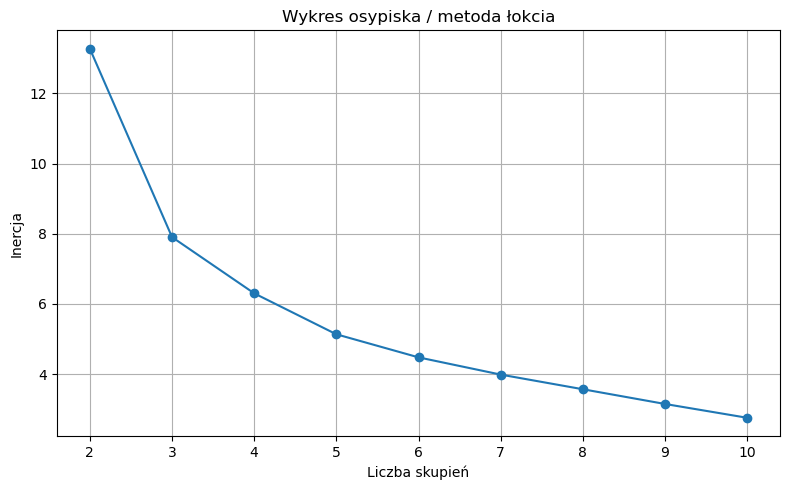

In [46]:
# Wykres osypiska / metoda łokcia

plt.figure(figsize=(8, 5))

plt.plot(
    clustering_metrics["Liczba skupień"],
    clustering_metrics["Inercja"],
    marker="o",
    linestyle="-"
)

plt.xlabel("Liczba skupień")
plt.ylabel("Inercja")
plt.title("Wykres osypiska / metoda łokcia")
plt.grid(True)
plt.tight_layout()
plt.show()

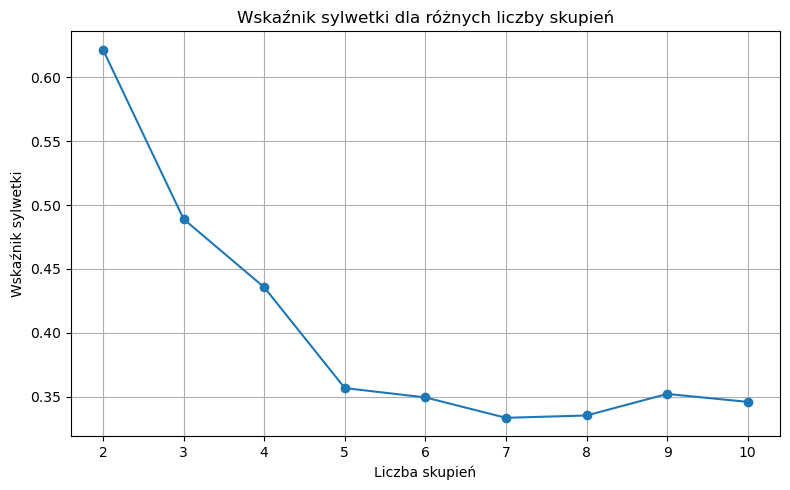

In [47]:
# Wykres wartości wskaźnika sylwetki dla różnych wartości k

plt.figure(figsize=(8, 5))

plt.plot(
    clustering_metrics["Liczba skupień"],
    clustering_metrics["Wskaźnik sylwetki"],
    marker="o",
    linestyle="-"
)

plt.xlabel("Liczba skupień")
plt.ylabel("Wskaźnik sylwetki")
plt.title("Wskaźnik sylwetki dla różnych liczby skupień")
plt.grid(True)
plt.tight_layout()
plt.show()

Wykres inercji pomaga ocenić, przy jakiej liczbie skupień poprawa zwartości grup zaczyna być coraz mniejsza.

Wskaźnik sylwetki pozwala dodatkowo sprawdzić, dla której liczby skupień obserwacje są relatywnie dobrze dopasowane do własnych grup i jednocześnie oddzielone od innych grup.

Jeżeli różne miary sugerują różne wartości `k`, nie musi to oznaczać błędu.  
W takiej sytuacji warto porównać kilka wariantów modelu także pod kątem interpretacji skupień.

## Co jeszcze można zrobić?

Po zbudowaniu pierwszego modelu można rozważyć kolejne warianty analizy:

- utworzenie zmiennych pochodnych, np. pola płatka i pola działki,
- porównanie różnych sposobów skalowania danych,
- sprawdzenie wpływu zmiennych silnie skorelowanych,
- zmianę hiperparametrów metody KMeans,
- porównanie KMeans z innymi metodami grupowania, np. aglomeracją, DBSCAN, GMM lub sieciami Kohonena,
- ocenę stabilności wyniku dla różnych wartości `random_state`.

W praktyce dobra analiza skupień rzadko kończy się na jednym modelu.  
Zwykle porównuje się kilka wariantów i wybiera ten, który jest jednocześnie poprawny metodycznie oraz sensowny interpretacyjnie.

Sprawdźmy jakie ustawienia (hiperparametry) oferuje metoda KMeans
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

## Dodatkowe miary oceny modelu

Oprócz wskaźnika sylwetki można wykorzystać także inne miary oceny jakości grupowania.

### Calinski-Harabasz Score

Wskaźnik Calinskiego-Harabasza porównuje zróżnicowanie między skupieniami ze zróżnicowaniem wewnątrz skupień.

Ogólna zasada interpretacji jest prosta:

- wyższa wartość oznacza lepsze rozdzielenie skupień,
- miara jest szczególnie przydatna do porównywania kilku modeli na tym samym zbiorze danych.

Nie należy interpretować tej miary za pomocą jednego uniwersalnego progu.

### Davies-Bouldin Score

Wskaźnik Daviesa-Bouldina ocenia podobieństwo skupień do siebie.

Ogólna zasada interpretacji:

- niższa wartość oznacza lepszy wynik,
- wartości bliższe 0 sugerują lepiej oddzielone skupienia,
- miara najlepiej sprawdza się przy porównywaniu kilku wariantów modelu na tych samych danych.

Również tutaj nie ma jednego uniwersalnego progu dobrej jakości klasteryzacji.     
    

## Wizualizacja skupień w przestrzeni 2D

Po przeprowadzeniu analizy skupień chcemy sprawdzić, czy otrzymane grupy wydają się dobrze rozdzielone.

Ponieważ dane zawierają kilka cech, trudno jest bezpośrednio zobaczyć ich strukturę na zwykłym wykresie.  
Dlatego wykorzystamy metody redukcji wymiarów, które pozwalają przedstawić obserwacje w przestrzeni dwuwymiarowej.

W tym celu użyjemy dwóch podejść:

- **PCA (analiza głównych składowych)** – metoda liniowa, która upraszcza dane przy zachowaniu możliwie dużej części ich zmienności,
- **t-SNE** – metoda nieliniowa, często używana do eksploracyjnej wizualizacji podobieństwa obserwacji.

Warto pamiętać, że taka wizualizacja jest jedynie pomocą interpretacyjną.  
Dobrze rozdzielone grupy na wykresie 2D są korzystnym sygnałem, ale nie stanowią samodzielnego dowodu wysokiej jakości segmentacji.

In [48]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def visualize_clusters(df, predictors, cluster_col, method='PCA'):
    """
    Wizualizuje skupienia w 2D przy użyciu PCA lub t-SNE.

    Parametry:
    - df: DataFrame zawierający dane,
    - predictors: lista kolumn używanych do redukcji wymiarów,
    - cluster_col: nazwa kolumny zawierającej przypisane skupienia,
    - method: 'PCA' lub 't-SNE' (domyślnie 'PCA').
    """

    # Redukcja wymiarów
    if method == 'PCA':
        reducer = PCA(n_components=2)
        x_label = "Pierwsza składowa PCA"
        y_label = "Druga składowa PCA"
        title = "Wizualizacja skupień w przestrzeni PCA"
    elif method == 't-SNE':
        reducer = TSNE(n_components=2, perplexity=30, random_state=seed)
        x_label = "Pierwszy wymiar t-SNE"
        y_label = "Drugi wymiar t-SNE"
        title = "Wizualizacja skupień w przestrzeni t-SNE"
    else:
        raise ValueError("Metoda musi być 'PCA' lub 't-SNE'")

    # Przekształcenie danych
    X_transformed = reducer.fit_transform(df[predictors])

    # Utworzenie pomocniczej ramki do wykresu
    df_transformed = df.copy()
    df_transformed['X1'] = X_transformed[:, 0]
    df_transformed['X2'] = X_transformed[:, 1]

    # Tworzenie wykresu
    plt.figure(figsize=(7, 6))

    sns.scatterplot(
        x='X1',
        y='X2',
        hue=cluster_col,
        palette='Set1',
        data=df_transformed,
        alpha=0.7
    )

    # Centroidy pokazujemy tylko dla PCA
    if method == 'PCA':
        centroids = df_transformed.groupby(cluster_col)[['X1', 'X2']].mean()

        plt.scatter(
            centroids['X1'],
            centroids['X2'],
            marker="X",
            s=200,
            c="black",
            label="Środki skupień"
        )

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend(title="Skupienie")
    plt.tight_layout()
    plt.show()

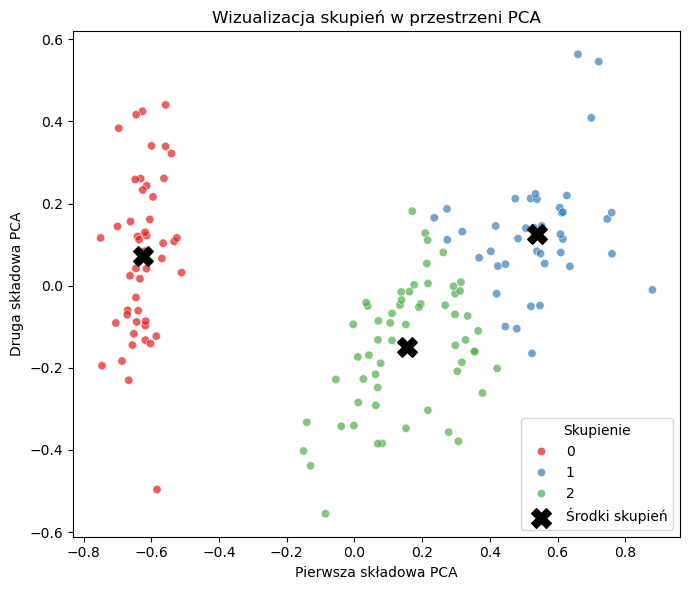

In [49]:
visualize_clusters(scaled_iris_df, predictors, 'predicted_class', method='PCA')

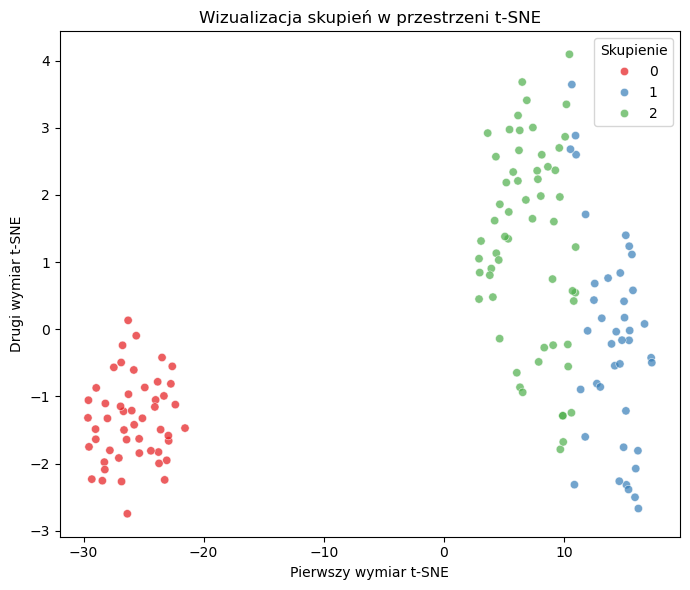

In [50]:
visualize_clusters(scaled_iris_df, predictors, 'predicted_class', method='t-SNE')

### Jak interpretować wykresy?

W przypadku PCA warto zwrócić uwagę, czy skupienia zajmują różne obszary przestrzeni i czy nie nakładają się nadmiernie na siebie.

W przypadku t-SNE interpretacja powinna być ostrożniejsza.  
Metoda ta dobrze pokazuje lokalne podobieństwa między obserwacjami, ale odległości globalne i położenie całych grup nie zawsze mają prostą interpretację.

Dlatego wykresy PCA i t-SNE traktujemy jako narzędzie wspomagające interpretację, a nie jako formalną miarę jakości modelu.

# Zadania rozszerzające do analizy skupień na zbiorze Iris

Poniższe zadania rozwijają analizę wykonaną w notebooku.  
Celem nie jest tylko uruchomienie kolejnych metod, ale także porównanie wyników, ocena jakości segmentacji oraz świadoma interpretacja uzyskanych skupień.

W zadaniach należy korzystać z przygotowanych wcześniej ramek danych:

- `iris_df` — dane oryginalne wraz ze zmienną referencyjną `species`,
- `scaled_iris_df` — dane przeskalowane,
- `predictors` — lista zmiennych używanych do analizy skupień,
- `species` — zmienna referencyjna, która nie jest używana do budowy modeli, ale służy do późniejszej oceny zgodności skupień z rzeczywistymi odmianami irysa.

---

# Zadanie 1 - Porównanie różnych metod analizy skupień

## Cel zadania

Rozszerz analizę skupień o inne metody grupowania danych i porównaj ich wyniki z modelem KMeans.

W notebooku został zbudowany model KMeans. Twoim zadaniem jest sprawdzenie, czy inne algorytmy grupowania prowadzą do podobnych lub lepszych wyników.

Uwzględnij co najmniej trzy spośród poniższych metod:

- aglomeracyjna analiza skupień,
- DBSCAN,
- Gaussian Mixture Model,
- sieci Kohonena / SOM,
- inna metoda grupowania wybrana samodzielnie.

## Co należy zrobić?

1. Zbuduj modele skupień za pomocą wybranych metod.
2. Dla każdej metody przypisz każdej obserwacji etykietę skupienia.
3. Zapisz wyniki w ramce danych jako osobne kolumny, np.:
   - `cluster_kmeans`,
   - `cluster_agglomerative`,
   - `cluster_dbscan`,
   - `cluster_gmm`.
4. Dla każdej metody przygotuj tabelę liczności skupień.
5. Dla każdej metody przygotuj tabelę kontyngencji: skupienie vs `species`.
6. Oblicz miary jakości:
   - Adjusted Rand Index względem `species`,
   - silhouette score,
   - Calinski-Harabasz Score,
   - Davies-Bouldin Score.
7. Przygotuj wspólną tabelę porównującą wyniki wszystkich metod.
8. Zwizualizuj wyniki metod na wykresie PCA.
9. Napisz krótką interpretację wyników.

## Podpowiedzi

In [51]:
#Do aglomeracyjnej analizy skupień można wykorzystać:
from sklearn.cluster import AgglomerativeClustering

agglomerative_model = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_agglomerative = agglomerative_model.fit_predict(scaled_iris_df[predictors])

In [52]:
#Do modelu GMM:
from sklearn.mixture import GaussianMixture

gmm_model = GaussianMixture(n_components=3, random_state=seed)
labels_gmm = gmm_model.fit_predict(scaled_iris_df[predictors])

In [53]:
#Do DBSCAN:
from sklearn.cluster import DBSCAN

dbscan_model = DBSCAN(eps=0.3, min_samples=5)
labels_dbscan = dbscan_model.fit_predict(scaled_iris_df[predictors])

W DBSCAN etykieta -1 oznacza obserwacje uznane za szum.
Dlatego przy interpretacji DBSCAN należy dodatkowo sprawdzić, ile obserwacji zostało zaklasyfikowanych jako szum.

# Odpowiedź

In [63]:
# Biblioteki
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [64]:
# Dane wejściowe
X = scaled_iris_df[predictors].copy()

# Wyniki Kmeans
kmeans_model = KMeans(n_clusters=3, random_state=seed, n_init=10)
iris_df["cluster_kmeans"] = kmeans_model.fit_predict(X)

# Dbscan

In [95]:
# Algorytm sam wykrywa liczbę skupień, a etykieta -1 oznacza obserwacje uznane za szum

dbscan_model = DBSCAN(eps=0.2, min_samples=5) #eps -> maksymalna odleglosc miedzy dwoma punktami; min_samples -> minimalna ilosc punktow w skupisku
labels_dbscan = dbscan_model.fit_predict(X)

iris_df["cluster_dbscan"] = labels_dbscan

# Liczba obserwacji oznaczonych jako szum
noise_count = np.sum(labels_dbscan == -1)
print("Liczba obserwacji uznanych za szum przez DBSCAN:", noise_count)

# Liczności skupień DBSCAN
iris_df["cluster_dbscan"].value_counts().sort_index()

Liczba obserwacji uznanych za szum przez DBSCAN: 5


cluster_dbscan
-1     5
 0    49
 1    96
Name: count, dtype: int64

# Sieć Kohonena

In [96]:
# Prosta implementacja sieci Kohonena SOM. Sieć ma 3 neurony, ponieważ w zbiorze Iris są 3 rzeczywiste odmiany kwiatów
class SimpleSOM:
    def __init__(self, n_neurons=3, n_features=4, learning_rate=0.5, sigma=1.0, n_iter=1000, random_state=42):
        self.n_neurons = n_neurons
        self.n_features = n_features
        self.learning_rate = learning_rate
        self.sigma = sigma
        self.n_iter = n_iter
        self.random_state = random_state
        
    def fit(self, X):
        rng = np.random.default_rng(self.random_state)
        self.weights = rng.normal(size=(self.n_neurons, self.n_features))
        
        for i in range(self.n_iter):
            x = X[rng.integers(0, X.shape[0])]
            
            distances = np.linalg.norm(self.weights - x, axis=1)
            winner = np.argmin(distances)
            
            lr = self.learning_rate * (1 - i / self.n_iter)
            sigma = self.sigma * (1 - i / self.n_iter)
            
            for neuron in range(self.n_neurons):
                distance_to_winner = abs(neuron - winner)
                influence = np.exp(-(distance_to_winner ** 2) / (2 * sigma ** 2))
                self.weights[neuron] += lr * influence * (x - self.weights[neuron])
        
        return self
    
    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis, :] - self.weights[np.newaxis, :, :], axis=2)
        return np.argmin(distances, axis=1)


som_model = SimpleSOM(
    n_neurons=3,
    n_features=X.shape[1],
    learning_rate=0.5,
    sigma=1.0,
    n_iter=1000,
    random_state=seed
)

som_model.fit(X.values)
labels_som = som_model.predict(X.values)

iris_df["cluster_som"] = labels_som

# Liczności skupień SOM
iris_df["cluster_som"].value_counts().sort_index()

cluster_som
0    50
1    51
2    49
Name: count, dtype: int64

# Spectral Clustering

In [97]:
# Metoda grafowa, która może dobrze działać, gdy skupienia nie są idealnie kuliste
spectral_model = SpectralClustering(
    n_clusters=3,
    affinity="nearest_neighbors",
    random_state=seed
)

labels_spectral = spectral_model.fit_predict(X)

iris_df["cluster_spectral"] = labels_spectral

# Liczności skupień Spectral Clustering
iris_df["cluster_spectral"].value_counts().sort_index()

cluster_spectral
0    50
1    67
2    33
Name: count, dtype: int64

In [98]:
# Tabela liczności skupień dla wszystkich metod
cluster_columns = [
    "cluster_kmeans",
    "cluster_dbscan",
    "cluster_som",
    "cluster_spectral"
]

for col in cluster_columns:
    print(f"\nLiczności skupień dla metody: {col}")
    display(iris_df[col].value_counts().sort_index())


Liczności skupień dla metody: cluster_kmeans


cluster_kmeans
0    50
1    41
2    59
Name: count, dtype: int64


Liczności skupień dla metody: cluster_dbscan


cluster_dbscan
-1     5
 0    49
 1    96
Name: count, dtype: int64


Liczności skupień dla metody: cluster_som


cluster_som
0    50
1    51
2    49
Name: count, dtype: int64


Liczności skupień dla metody: cluster_spectral


cluster_spectral
0    50
1    67
2    33
Name: count, dtype: int64

In [99]:
# Tabela kontyngencji, które pokazują, jak skupienia uzyskane przez każdą metodę odpowiadają rzeczywistym odmianom
for col in cluster_columns:
    print(f"\nTabela kontyngencji: {col} vs species")
    display(pd.crosstab(iris_df[col], iris_df["species"]))


Tabela kontyngencji: cluster_kmeans vs species


species,setosa,versicolor,virginica
cluster_kmeans,,,
0,50,0,0
1,0,5,36
2,0,45,14



Tabela kontyngencji: cluster_dbscan vs species


species,setosa,versicolor,virginica
cluster_dbscan,,,
-1,1,0,4
0,49,0,0
1,0,50,46



Tabela kontyngencji: cluster_som vs species


species,setosa,versicolor,virginica
cluster_som,,,
0,50,0,0
1,0,40,11
2,0,10,39



Tabela kontyngencji: cluster_spectral vs species


species,setosa,versicolor,virginica
cluster_spectral,,,
0,50,0,0
1,0,50,17
2,0,0,33


In [100]:
# Miary jakości grupowania: ARI, silhouette score, Calinski-Harabasz Score oraz Davies-Bouldin Score
def calculate_clustering_metrics(labels, method_name):
    unique_labels = np.unique(labels)
    
    if len(unique_labels) < 2:
        return {
            "method": method_name,
            "ARI": adjusted_rand_score(iris_df["species"], labels),
            "silhouette_score": np.nan,
            "calinski_harabasz_score": np.nan,
            "davies_bouldin_score": np.nan,
            "number_of_clusters": len(unique_labels),
            "noise_points": np.sum(labels == -1)
        }
    
    return {
        "method": method_name,
        "ARI": adjusted_rand_score(iris_df["species"], labels),
        "silhouette_score": silhouette_score(X, labels),
        "calinski_harabasz_score": calinski_harabasz_score(X, labels),
        "davies_bouldin_score": davies_bouldin_score(X, labels),
        "number_of_clusters": len(unique_labels[unique_labels != -1]),
        "noise_points": np.sum(labels == -1)
    }


metrics_results = []

metrics_results.append(calculate_clustering_metrics(iris_df["cluster_kmeans"], "KMeans"))
metrics_results.append(calculate_clustering_metrics(iris_df["cluster_dbscan"], "DBSCAN"))
metrics_results.append(calculate_clustering_metrics(iris_df["cluster_som"], "SOM"))
metrics_results.append(calculate_clustering_metrics(iris_df["cluster_spectral"], "Spectral Clustering"))

metrics_df = pd.DataFrame(metrics_results)
metrics_df

,method,ARI,silhouette_score,calinski_harabasz_score,davies_bouldin_score,number_of_clusters,noise_points
0,KMeans,0.689756,0.489012,326.243064,0.792616,3,0
1,DBSCAN,0.550317,0.517863,155.868108,3.626407,2,5
2,SOM,0.663709,0.478923,323.933823,0.806592,3,0
3,Spectral Clustering,0.719584,0.496015,318.548785,0.771191,3,0


In [101]:
# Redukcja PCA
pca = PCA(n_components=2, random_state=seed)
pca_result = pca.fit_transform(X)

iris_df["pca_1"] = pca_result[:, 0]
iris_df["pca_2"] = pca_result[:, 1]

print("Wyjaśniona wariancja przez PCA:")
print(pca.explained_variance_ratio_)
print("Suma wyjaśnionej wariancji:", pca.explained_variance_ratio_.sum())

Wyjaśniona wariancja przez PCA:
[0.81274443 0.1466675 ]
Suma wyjaśnionej wariancji: 0.959411929408267


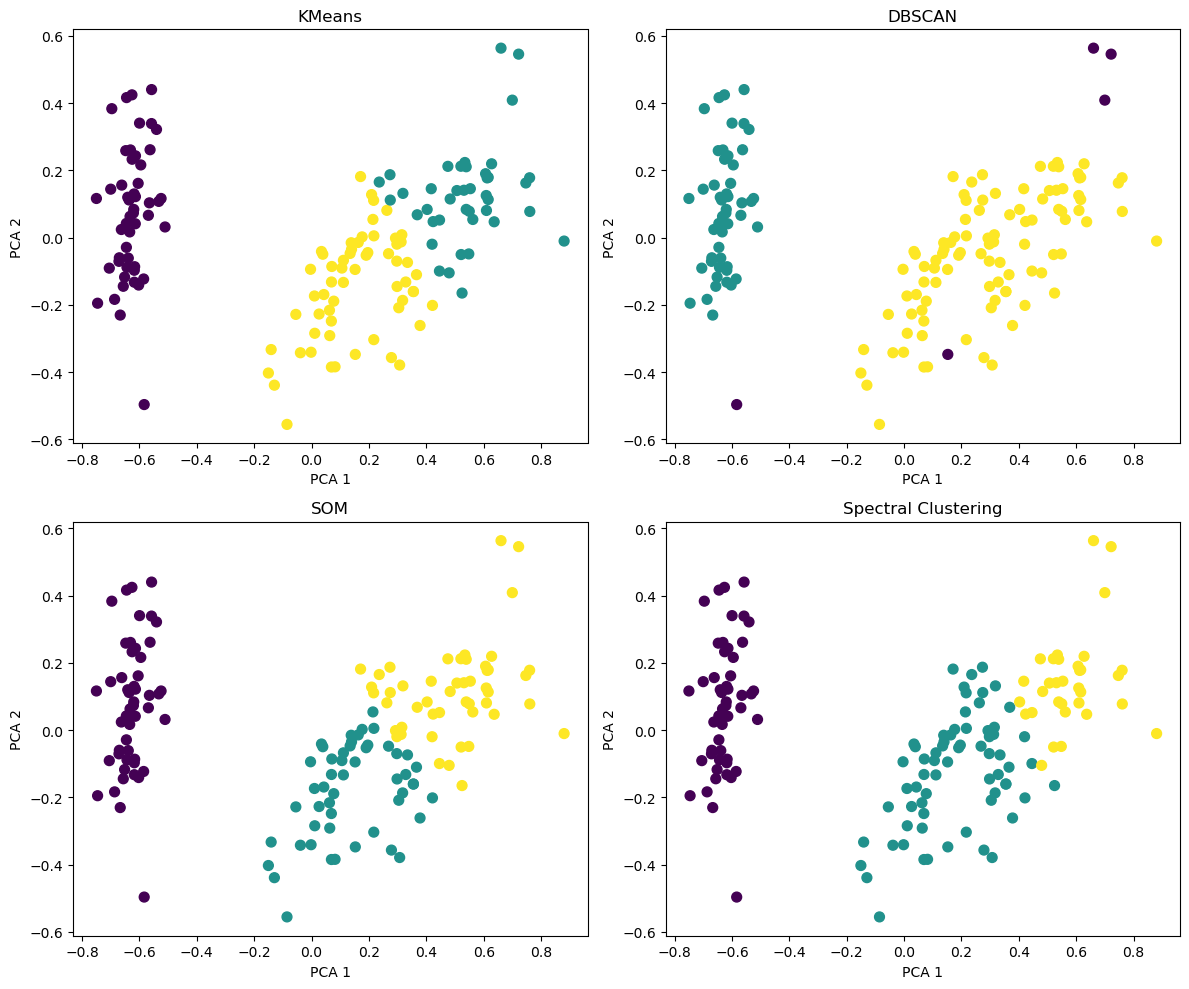

In [102]:
# Wizualizacja PCA
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

methods_to_plot = {
    "KMeans": "cluster_kmeans",
    "DBSCAN": "cluster_dbscan",
    "SOM": "cluster_som",
    "Spectral Clustering": "cluster_spectral"
}

for ax, (title, col) in zip(axes.ravel(), methods_to_plot.items()):
    scatter = ax.scatter(
        iris_df["pca_1"],
        iris_df["pca_2"],
        c=iris_df[col],
        cmap="viridis",
        s=50
    )
    ax.set_title(title)
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")

plt.tight_layout()
plt.show()

In [103]:
# Sortowanie tabeli porównawczej według ARI, czyli miary zgodności skupień z rzeczywistymi gatunkami
metrics_df.sort_values(by="ARI", ascending=False)

,method,ARI,silhouette_score,calinski_harabasz_score,davies_bouldin_score,number_of_clusters,noise_points
3,Spectral Clustering,0.719584,0.496015,318.548785,0.771191,3,0
0,KMeans,0.689756,0.489012,326.243064,0.792616,3,0
2,SOM,0.663709,0.478923,323.933823,0.806592,3,0
1,DBSCAN,0.550317,0.517863,155.868108,3.626407,2,5


## Wnioski końcowe

Najlepszy wynik względem rzeczywistych odmian irysa uzyskała metoda **Spectral Clustering**, dla której wartość ARI = 0.72. Oznacza to, że ta metoda najlepiej odtworzyła rzeczywisty podział danych na gatunki `setosa`, `versicolor` i `virginica`.

Model **KMeans** oraz **SOM** również uzyskał dobry wynik, ale był nieco słabszy od Spectral Clustering. Wszystkie te trzy metody poprawnie oddzieliły klasę `setosa`, natomiast największe różnice pojawiły się przy rozdzielaniu gatunków `versicolor` i `virginica`.

Metoda **DBSCAN** uzyskała niższy wynik ARI = 0.55. Dodatkowo utworzyła tylko 2 skupienia oraz oznaczyła 5 obserwacji jako szum. DBSCAN bardzo dobrze oddzielił gatunek `setosa`, ale połączył większość obserwacji `versicolor` i `virginica` w jedno skupienie, dlatego gorzej odtworzył rzeczywisty podział na 3 gatunki.

Najwyższy wynik **silhouette score** uzyskał **DBSCAN**, z wartością 0.52. Nie oznacza to jednak, że był najlepszy względem rzeczywistych gatunków, ponieważ silhouette score ocenia geometryczną zwartość i separację skupień, a nie zgodność z etykietami `species`.

Według miary **Calinski-Harabasz Score** najlepszy był **KMeans** z wynikiem 326. Według **Davies-Bouldin Score** najlepszy był **Spectral Clustering**, ponieważ miał najniższą wartość tej miary, równą 0.77.

## Pytania do interpretacji
- Która metoda uzyskała najwyższy ARI względem rzeczywistych odmian irysa?
- Która metoda uzyskała najlepszy wynik według silhouette score?
- Czy najlepsza metoda według ARI jest jednocześnie najlepsza według innych miar?
- Czy wyniki DBSCAN są łatwe do porównania z KMeans?

# Odpowiedzi

- Najwyższy ARI uzyskała metoda Spectral Clustering

- Najlepszy wynik silhouette score uzyskał DBSCAN

- Nie w pełni. Najlepsza według ARI była metoda Spectral Clustering, ale według silhouette score najlepszy był*DBSCAN, a według Calinski-Harabasz Score najlepszy był KMeans. Spectral Clustering był natomiast najlepszy według Davies-Bouldin Score, ponieważ miał najniższą wartość tej miary.

- Nie do końca. KMeans został ustawiony na 3 klastry, zgodnie z liczbą gatunków irysa, natomiast DBSCAN sam wyznaczył strukturę danych: utworzył tylko 2 skupienia i oznaczył 5 obserwacji jako szum. Dlatego DBSCAN nie jest bezpośrednio porównywalny z KMeans.

# Zadanie 2 - Ocena stabilności wyniku analizy skupień

## Cel zadania

Sprawdź, czy wynik analizy skupień jest stabilny, czyli czy niewielkie zmiany w danych prowadzą do podobnego podziału obserwacji.

W analizie skupień wysoki wynik pojedynczego modelu nie zawsze wystarcza.
Model może dobrze wyglądać dla jednego zbioru danych, ale dawać inne wyniki po niewielkiej zmianie próby.

W tym zadaniu wykorzystasz próbki bootstrapowe do oceny stabilności modelu.

## Co należy zrobić?
- Zbuduj model referencyjny KMeans na pełnym zbiorze danych.
- Zapisz etykiety skupień z modelu referencyjnego.
- Wylosuj wiele prób bootstrapowych z danych, np. 100.
- Dla każdej próby bootstrapowej:
    - zbuduj osobny model KMeans,
    - przypisz etykiety skupień do oryginalnego zbioru danych,
    - porównaj te etykiety z etykietami modelu referencyjnego za pomocą ARI.
- Zapisz wartości ARI w liście.
- Narysuj histogram wartości ARI.
- Oblicz średnią, medianę, minimum, maksimum i odchylenie standardowe wartości ARI.
- Zinterpretuj stabilność modelu.

## Jak interpretować wynik?

W tym zadaniu ARI nie porównuje modelu ze zmienną species.

ARI porównuje:

- etykiety z modelu referencyjnego,
- etykiety z modeli uczonych na próbkach bootstrapowych.

Interpretacja:

- wysokie wartości ARI oznaczają, że model jest stabilny,
- niskie wartości ARI oznaczają, że niewielkie zmiany w danych prowadzą do innego podziału,
- duże zróżnicowanie ARI oznacza, że model jest wrażliwy na próbę uczącą.

## Rozszerzenie zadania

Wykonaj tę samą procedurę dla różnych wartości liczby skupień

## Pytania do interpretacji
- Czy model KMeans jest stabilny dla k = 3?
- Czy inne wartości k dają bardziej stabilne wyniki?
- Czy najbardziej stabilny model jest jednocześnie najbardziej zgodny ze zmienną species?
- Czy stabilność modelu oznacza automatycznie, że skupienia mają sens merytoryczny?
- Czy model niestabilny powinien być używany do interpretacji segmentów?

In [104]:
# Biblioteki
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dane wejściowe
X = scaled_iris_df[predictors].copy()

In [105]:
# Budujemy referencyjny model KMeans na pełnym zbiorze danych
# Etykiety z tego modelu będą punktem odniesienia dla modeli uczonych na próbkach bootstrapowych
reference_kmeans = KMeans(
    n_clusters=3,
    random_state=seed,
    n_init=10
)

reference_kmeans.fit(X)

reference_labels = reference_kmeans.labels_

iris_df["cluster_kmeans_reference"] = reference_labels

pd.Series(reference_labels).value_counts().sort_index()

0    50
1    41
2    59
Name: count, dtype: int64

In [106]:
# Wykonujemy bootstrap
# W każdej iteracji losujemy próbkę z powtórzeniami, uczymy osobny model KMeans
# a następnie przypisujemy etykiety wszystkim obserwacjom z oryginalnego zbioru
# Potem porównujemy je z modelem referencyjnym za pomocą ARI.
n_bootstrap = 100
ari_scores = []

rng = np.random.default_rng(seed)

for i in range(n_bootstrap):
    bootstrap_indices = rng.choice(
        X.index,
        size=len(X),
        replace=True
    )
    
    X_bootstrap = X.loc[bootstrap_indices]
    
    bootstrap_kmeans = KMeans(
        n_clusters=3,
        random_state=seed + i,
        n_init=10
    )
    
    bootstrap_kmeans.fit(X_bootstrap)
    
    bootstrap_labels = bootstrap_kmeans.predict(X)
    
    ari = adjusted_rand_score(reference_labels, bootstrap_labels)
    ari_scores.append(ari)

ari_scores[:10]

[0.9418907876494061,
 0.9608021382565117,
 0.9608021382565117,
 0.680017455155198,
 0.8688008364803874,
 0.7167570424013383,
 1.0,
 0.9043467900066662,
 0.9608021382565117,
 1.0]

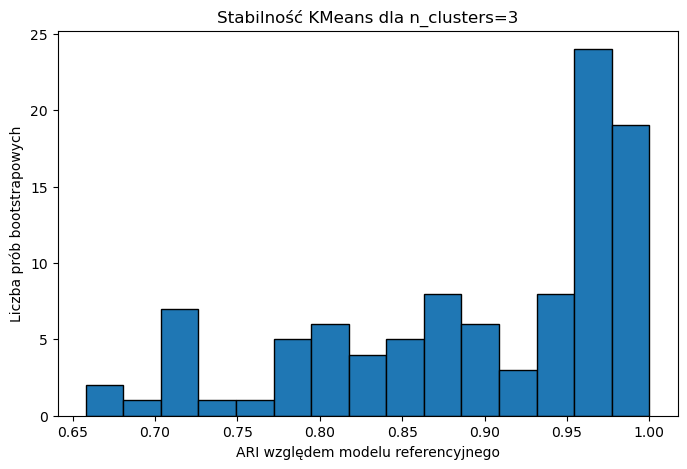

In [107]:
# Histogram wartości ARI
plt.figure(figsize=(8, 5))
plt.hist(ari_scores, bins=15, edgecolor="black")
plt.title("Stabilność KMeans dla n_clusters=3")
plt.xlabel("ARI względem modelu referencyjnego")
plt.ylabel("Liczba prób bootstrapowych")
plt.show()

In [108]:
# Podstawowe statystyki wartości Ari: średnia, mediana, min, max i std
stability_summary = pd.DataFrame({
    "mean_ARI": [np.mean(ari_scores)],
    "median_ARI": [np.median(ari_scores)],
    "min_ARI": [np.min(ari_scores)],
    "max_ARI": [np.max(ari_scores)],
    "std_ARI": [np.std(ari_scores)]
})

stability_summary

,mean_ARI,median_ARI,min_ARI,max_ARI,std_ARI
0,0.894809,0.941891,0.657895,1.0,0.094502


# Wnioski

Dla modelu KMeans z liczbą skupień równą 3 średnia wartość ARI wyniosła 0.89, a mediana 0.94. Oznacza to, że model jest dość stabilny, ponieważ w większości prób bootstrapowych uzyskany podział był bardzo podobny do modelu referencyjnego.

Minimalna wartość ARI wyniosła jednak 0.66, co pokazuje, że w niektórych próbach bootstrapowych wynik klasteryzacji różnił się zauważalnie od modelu referencyjnego. Odchylenie standardowe 0.095 wskazuje na umiarkowane zróżnicowanie wyników.

Można więc stwierdzić, że KMeans dla `n_clusters=3` jest ogólnie stabilny, ale nie całkowicie odporny na zmiany w próbie uczącej.

In [109]:
# Stabilność Kmeans dla różnych wartości liczby skupień
cluster_range = range(2, 8)
bootstrap_results = []

for k in cluster_range:
    reference_model = KMeans(
        n_clusters=k,
        random_state=seed,
        n_init=10
    )
    
    reference_model.fit(X)
    reference_labels_k = reference_model.labels_
    
    ari_scores_k = []
    
    for i in range(n_bootstrap):
        bootstrap_indices = rng.choice(
            X.index,
            size=len(X),
            replace=True
        )
        
        X_bootstrap = X.loc[bootstrap_indices]
        
        bootstrap_model = KMeans(
            n_clusters=k,
            random_state=seed + i,
            n_init=10
        )
        
        bootstrap_model.fit(X_bootstrap)
        bootstrap_labels_k = bootstrap_model.predict(X)
        
        ari = adjusted_rand_score(reference_labels_k, bootstrap_labels_k)
        ari_scores_k.append(ari)
    
    bootstrap_results.append({
        "n_clusters": k,
        "mean_ARI": np.mean(ari_scores_k),
        "median_ARI": np.median(ari_scores_k),
        "min_ARI": np.min(ari_scores_k),
        "max_ARI": np.max(ari_scores_k),
        "std_ARI": np.std(ari_scores_k)
    })

bootstrap_results_df = pd.DataFrame(bootstrap_results)
bootstrap_results_df

,n_clusters,mean_ARI,median_ARI,min_ARI,max_ARI,std_ARI
0,2,0.999196,1.000000,0.946530,1.000000,0.005933
1,3,0.891060,0.923445,0.680017,1.000000,0.095172
2,4,0.842671,0.893167,0.473717,1.000000,0.153913
3,5,0.801573,0.801924,0.468404,0.961693,0.105101
4,6,0.732531,0.721698,0.451524,0.985361,0.117199
5,7,0.669625,0.666346,0.504883,0.882425,0.087303


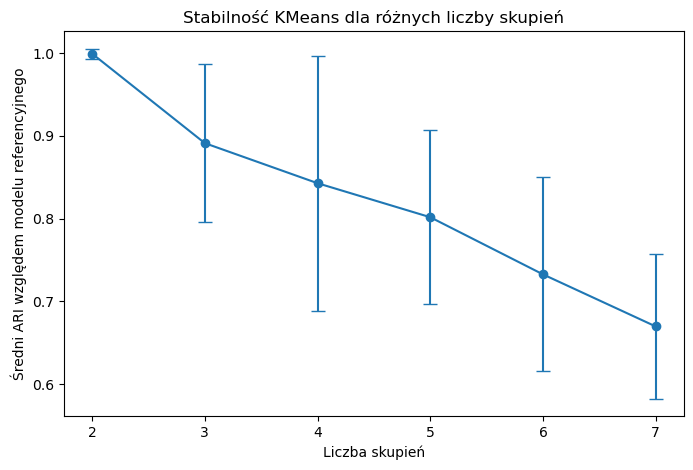

In [110]:
# Wykres stabilności różnych skupień
plt.figure(figsize=(8, 5))
plt.errorbar(
    bootstrap_results_df["n_clusters"],
    bootstrap_results_df["mean_ARI"],
    yerr=bootstrap_results_df["std_ARI"],
    marker="o",
    capsize=5
)

plt.title("Stabilność KMeans dla różnych liczby skupień")
plt.xlabel("Liczba skupień")
plt.ylabel("Średni ARI względem modelu referencyjnego")
plt.xticks(list(cluster_range))
plt.show()

# Wnioski

W rozszerzeniu porównano stabilność KMeans dla liczby skupień od 2 do 7. Najbardziej stabilny okazał się wariant z **2 skupieniami**, dla którego średni ARI wyniósł 0.9992, mediana 1, a odchylenie standardowe tylko 0.0059. Oznacza to, że podział na 2 grupy jest prawie identyczny w kolejnych próbach bootstrapowych.

Dla **3 skupień** stabilność nadal była wysoka, ale niższa niż dla 2 skupień. Średni ARI wyniósł 0.89, a odchylenie standardowe 0.095.

Wraz ze wzrostem liczby skupień stabilność modelu stopniowo malała. Dla 4-7 skupień średni ARI był coraz niższy, a wyniki bardziej zmienne. Oznacza to, że większa liczba klastrów powoduje większą wrażliwość modelu na dobór próby bootstrapowej.

## Odpowiedzi na pytania do interpretacji

**Czy model KMeans jest stabilny dla k = 3?**

Tak, model KMeans dla `k = 3` można uznać za dość stabilny. Większość modeli bootstrapowych dawała podział podobny do modelu referencyjnego. Nie jest to jednak stabilność idealna, ponieważ minimalny ARI był niski.

**Czy inne wartości k dają bardziej stabilne wyniki?**

Tak. Najbardziej stabilny był model dla `k = 2`. Podział na 2 skupienia był prawie identyczny w kolejnych próbach bootstrapowych.

**Czy najbardziej stabilny model jest jednocześnie najbardziej zgodny ze zmienną species?**

Nie musi być. W tym przypadku najbardziej stabilny był model dla `k = 2`, ale zmienna `species` ma 3 klasy. Dlatego model z `k = 2` może być bardzo stabilny, ale nie odtwarza pełnego podziału na trzy odmiany irysa.

**Czy stabilność modelu oznacza automatycznie, że skupienia mają sens merytoryczny?**

Nie. Stabilność oznacza tylko, że model daje podobne wyniki po niewielkich zmianach w danych.

**Czy model niestabilny powinien być używany do interpretacji segmentów?**

Raczej nie, ponieważ niewielkie zmiany w danych mogą prowadzić do innego podziału obserwacji. W takiej sytuacji interpretacja segmentów byłaby mało wiarygodna.